# Pure Covariate Shift — Binary WCP Ablation (σ=3)

**Research question**: Does the binary WCP bottleneck (RAPS K=2 → all-or-nothing deferral)
persist under *pure* covariate shift (no label shift), and does GNN-DRE's higher ESS help
more under controlled shift?

## Controlled setup
CheXpert randomly split 60/40: Source (clean) vs Target (Gaussian blur σ=3).
Labels are **identical** — no label shift by construction.

```
CheXpert (64,534 total)
├── Source 60% (clean features from chexpert_densenet121-res224-chex_features.npz)
│     ├── Train: 75% of source (~29k) — LR + GNN training
│     └── Cal:   25% of source (~9.7k) — WCP calibration
└── Target 40% (blurred features from chexpert_target_perturbed_sigma3.0_features.npz)
      ├── Pool:  50% of target (~12.9k) — DRE fitting
      └── Test:  50% of target (~12.9k) — WCP evaluation
```

## Three methods compared (all at α = 0.10)

| Method | DRE feature space | DRE PCA | Weight clip |
|--------|-------------------|---------|-------------|
| **Standard CP** | — | — | — |
| **WCP-LR-c** | 1024-dim raw features | PCA(4) | 20.0 |
| **WCP-GNN** | 7-dim GNN probs | — | 20.0 |

**Key question**: Under pure covariate shift (no label shift), does higher ESS (GNN-DRE)
translate to lower/more-controlled deferral? α is swept coarsely (0.10 step) to show
sudden "bumps" where q̂ crosses the RAPS threshold.

In [1]:
import sys
import warnings
warnings.filterwarnings('ignore')
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score

ROOT = Path('/Users/amo/programData/wcp-l2d')
if str(ROOT / 'src') not in sys.path:
    sys.path.insert(0, str(ROOT / 'src'))

from wcp_l2d.dre import AdaptiveDRE
from wcp_l2d.features import ExtractedFeatures
from wcp_l2d.gnn import build_adjacency_matrix, train_gnn
from wcp_l2d.pathologies import COMMON_PATHOLOGIES
from wcp_l2d.evaluation import evaluate_standard_cp, evaluate_wcp
from wcp_l2d.conformal import ConformalPredictor, WeightedConformalPredictor

# --- Config ---
SIGMA  = 3.0
SEED   = 42
ALPHA  = 0.10
EXPERT = 0.85
K      = len(COMMON_PATHOLOGIES)
DEVICE = 'mps' if torch.backends.mps.is_available() else 'cpu'
N_EPOCHS    = 50
WEIGHT_CLIP = 20.0
ALPHAS      = np.arange(0.05, 0.55, 0.05)   # step 0.05: 0.05, 0.10, ..., 0.50

FEAT_DIR        = ROOT / 'data' / 'features'
PERTURBED_CACHE = FEAT_DIR / f'chexpert_target_perturbed_sigma{SIGMA:.1f}_features.npz'

np.random.seed(SEED)
torch.manual_seed(SEED)
plt.rcParams.update({
    'figure.dpi': 100, 'figure.facecolor': 'white',
    'axes.grid': True, 'grid.alpha': 0.3,
})

print(f'Device:           {DEVICE}')
print(f'SIGMA:            {SIGMA}')
print(f'ALPHA:            {ALPHA}')
print(f'ALPHAS (sweep):   {np.round(ALPHAS, 2).tolist()}')
print(f'Pathologies:      {COMMON_PATHOLOGIES}')
print(f'Perturbed cache:  {PERTURBED_CACHE}')
print(f'Cache exists:     {PERTURBED_CACHE.exists()}')

Device:           mps
SIGMA:            3.0
ALPHA:            0.1
ALPHAS (sweep):   [0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5]
Pathologies:      ['Atelectasis', 'Cardiomegaly', 'Consolidation', 'Edema', 'Effusion', 'Pneumonia', 'Pneumothorax']
Perturbed cache:  /Users/amo/programData/wcp-l2d/data/features/chexpert_target_perturbed_sigma3.0_features.npz
Cache exists:     True


## 1. Load Features

Same 60/40 index split as `synthetic_covariate_shift_scrc.ipynb` (same SEED, same permutation).

In [2]:
# Load clean CheXpert features
chex = ExtractedFeatures.load(FEAT_DIR / 'chexpert_densenet121-res224-chex_features.npz')
print(f'CheXpert: {chex.features.shape}  labels: {chex.labels.shape}')

# 60/40 source/target split (same permutation as SCRC notebook)
rng      = np.random.RandomState(SEED)
all_pos  = rng.permutation(len(chex.features))
n_source = int(0.60 * len(chex.features))
source_pos = all_pos[:n_source]
target_pos = all_pos[n_source:]

X_source_raw = chex.features[source_pos]   # clean
Y_source     = chex.labels[source_pos]
Y_target     = chex.labels[target_pos]     # same labels — no label shift

# Load perturbed target features (must exist; run extract_perturbed_features.py if missing)
assert PERTURBED_CACHE.exists(), (
    f'Cache not found: {PERTURBED_CACHE}\n'
    f'Run: uv run python scripts/extract_perturbed_features.py {SIGMA}'
)
_cache       = np.load(PERTURBED_CACHE, allow_pickle=True)
X_target_raw = _cache['features']  # blurred DenseNet features

assert X_target_raw.shape == (len(target_pos), 1024), \
    f'Shape mismatch: {X_target_raw.shape} vs expected ({len(target_pos)}, 1024)'

print(f'Source:  {X_source_raw.shape}  (60% clean)')
print(f'Target:  {X_target_raw.shape}  (40% blurred σ={SIGMA})')
print(f'\nLabel shift check (Δ should be ≈ 0):')
print(f'{"Pathology":15s} | {"Source":8s} | {"Target":8s} | {"Delta":8s}')
print('-' * 50)
for k, name in enumerate(COMMON_PATHOLOGIES):
    sp = np.nanmean(Y_source[:, k])
    tp = np.nanmean(Y_target[:, k])
    print(f'{name:15s} | {sp:8.4f} | {tp:8.4f} | {tp-sp:+8.4f}')

CheXpert: (64534, 1024)  labels: (64534, 7)
Source:  (38720, 1024)  (60% clean)
Target:  (25814, 1024)  (40% blurred σ=3.0)

Label shift check (Δ should be ≈ 0):
Pathology       | Source   | Target   | Delta   
--------------------------------------------------
Atelectasis     |   0.4706 |   0.4688 |  -0.0018
Cardiomegaly    |   0.3369 |   0.3413 |  +0.0044
Consolidation   |   0.1904 |   0.1975 |  +0.0070
Edema           |   0.4203 |   0.4196 |  -0.0007
Effusion        |   0.4658 |   0.4703 |  +0.0046
Pneumonia       |   0.1630 |   0.1559 |  -0.0071
Pneumothorax    |   0.1151 |   0.1186 |  +0.0035


## 2. Sub-splits + StandardScaler

```
Source (60%)
  ├── Train (75%) → LR + GNN training
  └── Cal   (25%) → WCP calibration
Target (40%)
  ├── Pool  (50%) → DRE fitting
  └── Test  (50%) → WCP evaluation
```

In [3]:
n_tr        = int(0.75 * n_source)
X_train_raw = X_source_raw[:n_tr]
Y_train     = Y_source[:n_tr]
X_cal_raw   = X_source_raw[n_tr:]
Y_cal       = Y_source[n_tr:]

n_pool     = len(X_target_raw) // 2
X_pool_raw = X_target_raw[:n_pool]
X_test_raw = X_target_raw[n_pool:]
Y_test     = Y_target[n_pool:]

# StandardScaler fitted on source train only
scaler  = StandardScaler().fit(X_train_raw)
X_train = scaler.transform(X_train_raw)
X_cal   = scaler.transform(X_cal_raw)
X_pool  = scaler.transform(X_pool_raw)
X_test  = scaler.transform(X_test_raw)

print(f'Train:  {X_train.shape}  (source, clean)')
print(f'Cal:    {X_cal.shape}    (source, clean → WCP calibration)')
print(f'Pool:   {X_pool.shape}   (target, blurred → DRE fitting)')
print(f'Test:   {X_test.shape}   (target, blurred → WCP evaluation)')

# Verify no label shift between cal and test
print(f'\nPure covariate shift check (Cal=source, Test=target; Δ should be ≈ 0):')
print(f'{"Pathology":15s} | {"Cal (src)":10s} | {"Test (tgt)":10s}')
print('-' * 42)
for k, name in enumerate(COMMON_PATHOLOGIES):
    print(f'{name:15s} | {np.nanmean(Y_cal[:, k]):10.4f} | {np.nanmean(Y_test[:, k]):10.4f}')

Train:  (29040, 1024)  (source, clean)
Cal:    (9680, 1024)    (source, clean → WCP calibration)
Pool:   (12907, 1024)   (target, blurred → DRE fitting)
Test:   (12907, 1024)   (target, blurred → WCP evaluation)

Pure covariate shift check (Cal=source, Test=target; Δ should be ≈ 0):
Pathology       | Cal (src)  | Test (tgt)
------------------------------------------
Atelectasis     |     0.4773 |     0.4758
Cardiomegaly    |     0.3409 |     0.3489
Consolidation   |     0.1896 |     0.1998
Edema           |     0.4326 |     0.4271
Effusion        |     0.4664 |     0.4812
Pneumonia       |     0.1643 |     0.1568
Pneumothorax    |     0.1155 |     0.1192


## 3. Build 7×7 Label Co-occurrence Adjacency Matrix

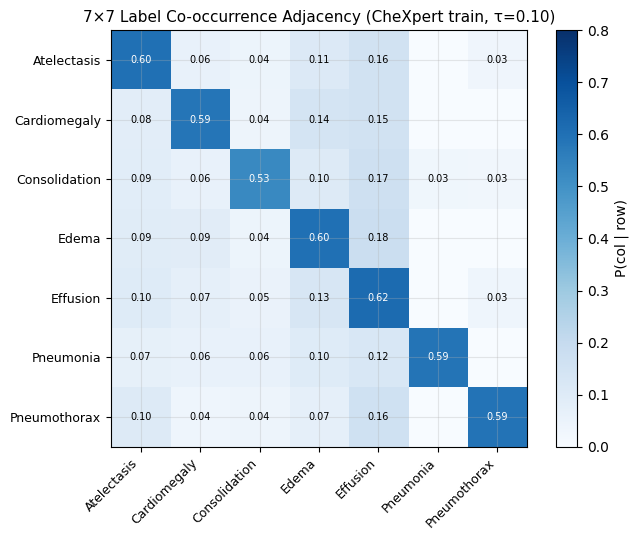

Non-zero off-diagonal: 34/42 (81%)


In [4]:
A = build_adjacency_matrix(Y_train, tau=0.10)
assert torch.allclose(A.sum(dim=1), torch.ones(K), atol=1e-5), 'Row sums must equal 1'

fig, ax = plt.subplots(figsize=(7, 5.5))
im = ax.imshow(A.numpy(), vmin=0, vmax=0.8, cmap='Blues')
ax.set_xticks(range(K)); ax.set_yticks(range(K))
ax.set_xticklabels(COMMON_PATHOLOGIES, rotation=45, ha='right', fontsize=9)
ax.set_yticklabels(COMMON_PATHOLOGIES, fontsize=9)
for i in range(K):
    for j in range(K):
        v = float(A[i, j])
        if v > 0:
            ax.text(j, i, f'{v:.2f}', ha='center', va='center', fontsize=7,
                    color='white' if v > 0.45 else 'black')
plt.colorbar(im, ax=ax, label='P(col | row)')
ax.set_title(f'7×7 Label Co-occurrence Adjacency (CheXpert train, τ=0.10)', fontsize=11)
plt.tight_layout()
plt.show()

n_nonzero = int((A > 0).sum()) - K
print(f'Non-zero off-diagonal: {n_nonzero}/{K*(K-1)} ({100*n_nonzero/(K*(K-1)):.0f}%)')

## 4. Train Binary LR Classifiers (GNN Residual Init)

In [5]:
lrs = []
for k, name in enumerate(COMMON_PATHOLOGIES):
    valid = ~np.isnan(Y_train[:, k])
    if valid.sum() < 10 or len(np.unique(Y_train[valid, k])) < 2:
        lrs.append(None)
        continue
    lr = LogisticRegression(solver='lbfgs', max_iter=1000, random_state=SEED)
    lr.fit(X_train[valid], Y_train[valid, k].astype(int))
    lrs.append(lr)


def get_logits_lr(lrs_, X_s):
    """[N, K] decision_function from 7 binary LRs (for GNN residual init)."""
    out = np.zeros((len(X_s), K), dtype=np.float32)
    for k, lr in enumerate(lrs_):
        if lr is not None:
            out[:, k] = lr.decision_function(X_s)
    return out


init_tr   = get_logits_lr(lrs, X_train)
init_cal  = get_logits_lr(lrs, X_cal)
init_pool = get_logits_lr(lrs, X_pool)
init_test = get_logits_lr(lrs, X_test)

print(f'LR classifiers trained: {sum(l is not None for l in lrs)}/{K}')
print(f'Init logits — train: {init_tr.shape}  cal: {init_cal.shape}')

LR classifiers trained: 7/7
Init logits — train: (29040, 7)  cal: (9680, 7)


## 5. Train LabelGCN

Training LabelGCN on mps (50 epochs, save_best=True) ...


Best val AUC: 0.8340  at epoch 38/50


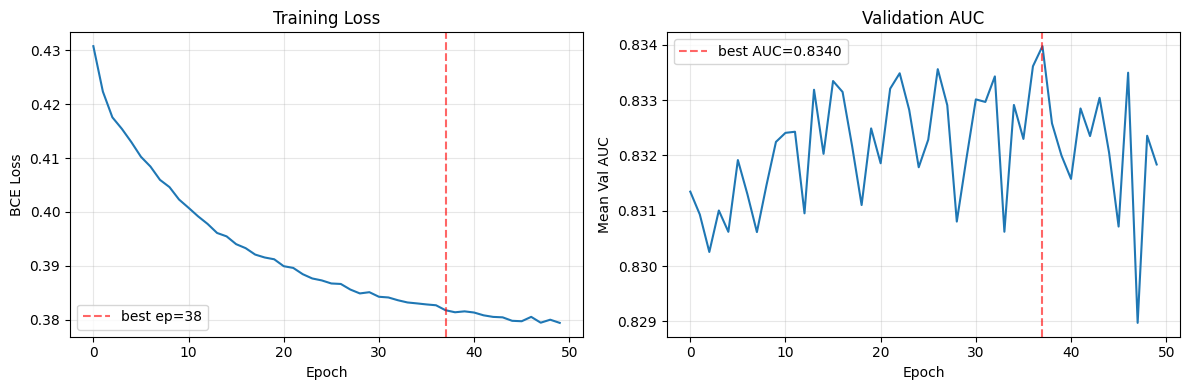

In [6]:
print(f'Training LabelGCN on {DEVICE} ({N_EPOCHS} epochs, save_best=True) ...')

gnn, history = train_gnn(
    features_train=X_train,
    labels_train=Y_train,
    features_val=X_cal,
    labels_val=Y_cal,
    adjacency=A,
    init_logits_train=init_tr,
    init_logits_val=init_cal,
    epochs=N_EPOCHS,
    save_best=True,
    batch_size=512,
    lr=1e-3,
    weight_decay=1e-4,
    device=DEVICE,
    verbose=False,
)

best_ep = history['best_epoch'][0]
print(f'Best val AUC: {max(history["val_auc"]):.4f}  at epoch {best_ep}/{N_EPOCHS}')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(history['train_loss'])
ax1.axvline(best_ep - 1, color='red', linestyle='--', alpha=0.6, label=f'best ep={best_ep}')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('BCE Loss'); ax1.set_title('Training Loss'); ax1.legend()
ax2.plot(history['val_auc'])
ax2.axvline(best_ep - 1, color='red', linestyle='--', alpha=0.6,
            label=f'best AUC={max(history["val_auc"]):.4f}')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Mean Val AUC'); ax2.set_title('Validation AUC')
ax2.legend()
plt.tight_layout()
plt.show()

## 6. GNN Probability Extraction & Target Test AUC

In [7]:
def gnn_probs_batch(model, X_s, init_np, batch_size=2048):
    """Batched GNN forward pass → sigmoid probabilities [N, K]."""
    model.eval()
    all_probs = []
    with torch.no_grad():
        for start in range(0, len(X_s), batch_size):
            end  = min(start + batch_size, len(X_s))
            Xt   = torch.tensor(X_s[start:end], dtype=torch.float32)
            it   = torch.tensor(init_np[start:end], dtype=torch.float32)
            logi = model(Xt, it).numpy()
            all_probs.append(1.0 / (1.0 + np.exp(-logi)))
    return np.vstack(all_probs)


p_train = gnn_probs_batch(gnn, X_train, init_tr)
p_cal   = gnn_probs_batch(gnn, X_cal,   init_cal)
p_pool  = gnn_probs_batch(gnn, X_pool,  init_pool)
p_test  = gnn_probs_batch(gnn, X_test,  init_test)

print(f'p_cal:  {p_cal.shape}   p_pool: {p_pool.shape}   p_test: {p_test.shape}')

# Per-pathology AUC on target test
rows = []
for k, name in enumerate(COMMON_PATHOLOGIES):
    valid = ~np.isnan(Y_test[:, k])
    if valid.sum() < 2 or len(np.unique(Y_test[valid, k])) < 2:
        rows.append({'Pathology': name, 'LR AUC': float('nan'), 'GNN AUC': float('nan')})
        continue
    y       = Y_test[valid, k]
    lr_auc  = roc_auc_score(y, lrs[k].predict_proba(X_test[valid])[:, 1]) if lrs[k] else float('nan')
    gnn_auc = roc_auc_score(y, p_test[valid, k])
    rows.append({'Pathology': name, 'LR AUC': round(lr_auc, 4), 'GNN AUC': round(gnn_auc, 4)})

auc_df = pd.DataFrame(rows).set_index('Pathology')
print('\nTarget test AUC (blurred σ=3, LR vs GNN):')
print(auc_df.to_string())
print(f'\nMean — LR: {auc_df["LR AUC"].mean():.4f}   GNN: {auc_df["GNN AUC"].mean():.4f}')

p_cal:  (9680, 7)   p_pool: (12907, 7)   p_test: (12907, 7)

Target test AUC (blurred σ=3, LR vs GNN):
               LR AUC  GNN AUC
Pathology                     
Atelectasis    0.7409   0.7663
Cardiomegaly   0.8382   0.8527
Consolidation  0.7845   0.8204
Edema          0.7791   0.8131
Effusion       0.8160   0.8388
Pneumonia      0.6902   0.7402
Pneumothorax   0.5999   0.6435

Mean — LR: 0.7498   GNN: 0.7821


## 7. Density Ratio Estimation

Two DRE variants using `AdaptiveDRE`:

| Variant | Feature space | PCA | Clip | Expected ESS |
|---------|---------------|-----|------|--------------|
| **LR-c** | 1024-dim raw | PCA(4) | 20.0 | ~7% (pure shift) |
| **GNN-c** | 7-dim probs | — | 20.0 | ~22–42% (pure shift) |

Source = CheXpert cal (clean); Target = CheXpert pool (blurred).

=== DRE Diagnostics (CheXpert cal set, pure covariate shift σ=3) ===
Method                    Domain AUC      ESS   ESS%   W mean   W med     W max
-------------------------------------------------------------------------------
LR-c (1024-dim,PCA4)          0.9981    139.8   1.4%    0.168   0.000    20.000
GNN-c (7-dim probs)           0.8643   1634.9  16.9%    0.874   0.382    20.000


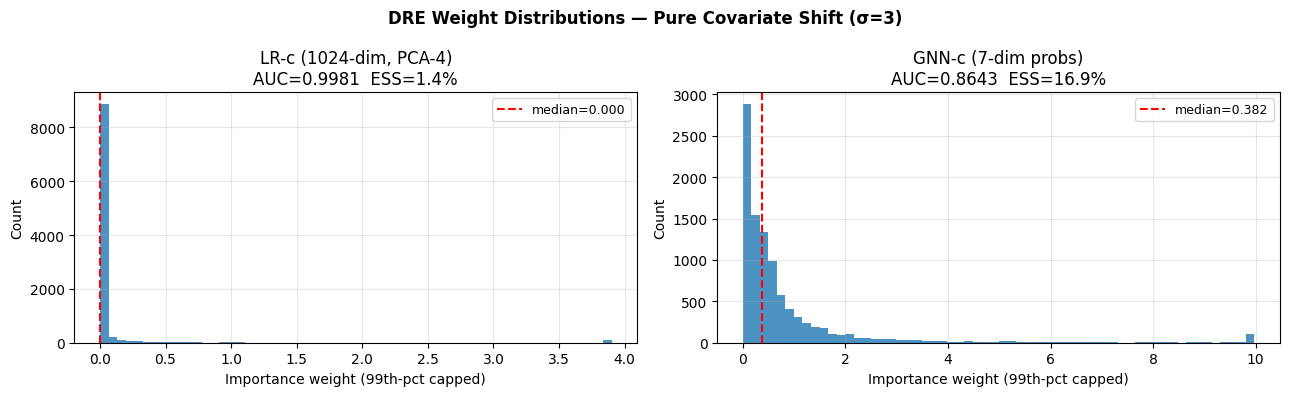

In [8]:
# LR-c DRE: 1024-dim raw features, PCA(4), clip=20
dre_lr = AdaptiveDRE(n_components=4, weight_clip=WEIGHT_CLIP, random_state=SEED)
dre_lr.fit(source_features=X_cal_raw, target_features=X_pool_raw)
w_cal_lr  = dre_lr.compute_weights(X_cal_raw)
w_test_lr = dre_lr.compute_weights(X_test_raw)
diag_lr   = dre_lr.diagnostics(X_cal_raw)

# GNN-c DRE: 7-dim GNN probs, no PCA, clip=20
dre_gnn = AdaptiveDRE(n_components=None, weight_clip=WEIGHT_CLIP, random_state=SEED)
dre_gnn.fit(source_features=p_cal, target_features=p_pool)
w_cal_gnn  = dre_gnn.compute_weights(p_cal)
w_test_gnn = dre_gnn.compute_weights(p_test)
diag_gnn   = dre_gnn.diagnostics(p_cal)

# Print diagnostics
print('=== DRE Diagnostics (CheXpert cal set, pure covariate shift σ=3) ===')
hdr = f"{'Method':<25} {'Domain AUC':>10} {'ESS':>8} {'ESS%':>6} {'W mean':>8} {'W med':>7} {'W max':>9}"
print(hdr); print('-' * len(hdr))
for name, diag in [('LR-c (1024-dim,PCA4)', diag_lr), ('GNN-c (7-dim probs)', diag_gnn)]:
    print(f'{name:<25} {diag.domain_auc:>10.4f} {diag.ess:>8.1f} '
          f'{diag.ess_fraction*100:>5.1f}% {diag.weight_mean:>8.3f} '
          f'{diag.weight_median:>7.3f} {diag.weight_max:>9.3f}')

# Weight distribution plots
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, (name, w, diag) in zip(axes, [
    ('LR-c (1024-dim, PCA-4)', w_cal_lr,  diag_lr),
    ('GNN-c (7-dim probs)',    w_cal_gnn, diag_gnn),
]):
    cap = np.percentile(w, 99)
    ax.hist(np.clip(w, 0, cap), bins=60, alpha=0.8, edgecolor='none')
    ax.axvline(float(np.median(w)), color='red', linestyle='--',
               label=f'median={np.median(w):.3f}')
    ax.set_title(f'{name}\nAUC={diag.domain_auc:.4f}  ESS={diag.ess_fraction*100:.1f}%')
    ax.set_xlabel('Importance weight (99th-pct capped)'); ax.set_ylabel('Count')
    ax.legend(fontsize=9)
plt.suptitle('DRE Weight Distributions — Pure Covariate Shift (σ=3)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

## 8. Per-Pathology Binary WCP

For each pathology:
1. Filter cal / test to non-NaN labels for that pathology.
2. Train per-pathology binary LR classifier on source train.
3. Compute binary RAPS logits `[-d, +d]`.
4. Run three methods across α ∈ [0.01, 0.50].

In [9]:
def binary_logits(clf, X):
    d = clf.decision_function(X)
    return np.column_stack([-d, d])


all_results = {}

for pathology in COMMON_PATHOLOGIES:
    k = COMMON_PATHOLOGIES.index(pathology)

    # Filter cal set to non-NaN
    c_mask = ~np.isnan(Y_cal[:, k])
    Xc, yc = X_cal[c_mask], Y_cal[c_mask, k].astype(int)

    # Filter test set to non-NaN
    t_mask = ~np.isnan(Y_test[:, k])
    Xt, yt = X_test[t_mask], Y_test[t_mask, k].astype(int)

    # Per-pathology binary LR classifier (fitted on source train)
    tr_mask = ~np.isnan(Y_train[:, k])
    clf_p   = LogisticRegression(solver='lbfgs', max_iter=1000, C=1.0, random_state=SEED)
    clf_p.fit(X_train[tr_mask], Y_train[tr_mask, k].astype(int))

    cal_lg  = binary_logits(clf_p, Xc)
    test_lg = binary_logits(clf_p, Xt)
    test_auc = roc_auc_score(yt, clf_p.predict_proba(Xt)[:, 1])

    # DRE weights for the filtered subsets
    wc_lr  = w_cal_lr[c_mask]
    wt_lr  = w_test_lr[t_mask]
    wc_gnn = w_cal_gnn[c_mask]
    wt_gnn = w_test_gnn[t_mask]

    # Run evaluations
    std_cp  = evaluate_standard_cp(cal_lg, yc, test_lg, yt, ALPHAS, expert_accuracy=EXPERT)
    wcp_lr  = evaluate_wcp(cal_lg, yc, wc_lr,  test_lg, yt, wt_lr,  ALPHAS, expert_accuracy=EXPERT)
    wcp_gnn = evaluate_wcp(cal_lg, yc, wc_gnn, test_lg, yt, wt_gnn, ALPHAS, expert_accuracy=EXPERT)

    all_results[pathology] = {
        'std_cp':   std_cp,
        'wcp_lr':   wcp_lr,
        'wcp_gnn':  wcp_gnn,
        'test_auc': test_auc,
        'n_cal':    int(c_mask.sum()),
        'n_test':   int(t_mask.sum()),
        'n_pos':    int(yt.sum()),
    }

    at10 = lambda rlist: min(rlist, key=lambda r: abs(r.alpha_or_threshold - ALPHA))
    std10 = at10(std_cp); gnn10 = at10(wcp_gnn)
    print(f'{pathology:<16}  AUC={test_auc:.3f}  '
          f'n_cal={c_mask.sum():>5}  n_pos={yt.sum():>4}  '
          f'Std_defer={std10.deferral_rate:.3f}  '
          f'WCP-GNN_defer={gnn10.deferral_rate:.3f}  '
          f'WCP-GNN_cov={gnn10.coverage_rate:.3f}')

print('\nDone.')

Atelectasis       AUC=0.741  n_cal= 4014  n_pos=2558  Std_defer=0.959  WCP-GNN_defer=0.959  WCP-GNN_cov=0.989


Cardiomegaly      AUC=0.838  n_cal= 4010  n_pos=1876  Std_defer=0.956  WCP-GNN_defer=0.956  WCP-GNN_cov=0.990


Consolidation     AUC=0.785  n_cal= 4125  n_pos=1102  Std_defer=0.956  WCP-GNN_defer=0.956  WCP-GNN_cov=0.991


Edema             AUC=0.779  n_cal= 5367  n_pos=3042  Std_defer=0.959  WCP-GNN_defer=0.959  WCP-GNN_cov=0.988


Effusion          AUC=0.816  n_cal= 6595  n_pos=4254  Std_defer=0.955  WCP-GNN_defer=0.955  WCP-GNN_cov=0.991


Pneumonia         AUC=0.690  n_cal= 2580  n_pos= 541  Std_defer=0.965  WCP-GNN_defer=0.965  WCP-GNN_cov=0.992


Pneumothorax      AUC=0.600  n_cal= 5566  n_pos= 881  Std_defer=0.257  WCP-GNN_defer=0.033  WCP-GNN_cov=0.848

Done.


## 9. Multi-Pathology Summary Table at α = 0.10

In [10]:
def at_alpha(res_list, a=ALPHA):
    return min(res_list, key=lambda r: abs(r.alpha_or_threshold - a))


rows = []
for path in COMMON_PATHOLOGIES:
    r   = all_results[path]
    std = at_alpha(r['std_cp'])
    lr  = at_alpha(r['wcp_lr'])
    gnn = at_alpha(r['wcp_gnn'])
    rows.append({
        'Pathology':      path,
        'Test AUC':       f"{r['test_auc']:.3f}",
        'Std Cov':        f"{std.coverage_rate:.3f}",
        'Std Defer':      f"{std.deferral_rate:.3f}",
        'LR-c Cov':       f"{lr.coverage_rate:.3f}",
        'LR-c Defer':     f"{lr.deferral_rate:.3f}",
        'GNN-c Cov':      f"{gnn.coverage_rate:.3f}",
        'GNN-c Defer':    f"{gnn.deferral_rate:.3f}",
    })

df_sum = pd.DataFrame(rows)
print(f'Binary WCP — Pure Covariate Shift (σ={SIGMA})  α={ALPHA}')
print('=' * 100)
print(df_sum.to_string(index=False))

print()
for col in ['Std Defer', 'LR-c Defer', 'GNN-c Defer', 'Std Cov', 'LR-c Cov', 'GNN-c Cov']:
    vals = pd.to_numeric(df_sum[col])
    print(f'  Mean {col}: {vals.mean():.3f}')

Binary WCP — Pure Covariate Shift (σ=3.0)  α=0.1
    Pathology Test AUC Std Cov Std Defer LR-c Cov LR-c Defer GNN-c Cov GNN-c Defer
  Atelectasis    0.741   0.989     0.959    0.989      0.959     0.989       0.959
 Cardiomegaly    0.838   0.990     0.956    0.990      0.956     0.990       0.956
Consolidation    0.785   0.991     0.956    0.991      0.956     0.991       0.956
        Edema    0.779   0.988     0.959    0.988      0.959     0.988       0.959
     Effusion    0.816   0.991     0.955    0.991      0.955     0.991       0.955
    Pneumonia    0.690   0.992     0.965    0.992      0.965     0.992       0.965
 Pneumothorax    0.600   0.908     0.257    0.793      0.092     0.848       0.033

  Mean Std Defer: 0.858
  Mean LR-c Defer: 0.835
  Mean GNN-c Defer: 0.826
  Mean Std Cov: 0.978
  Mean LR-c Cov: 0.962
  Mean GNN-c Cov: 0.970


## 10. Deferral Rate vs Confidence Level

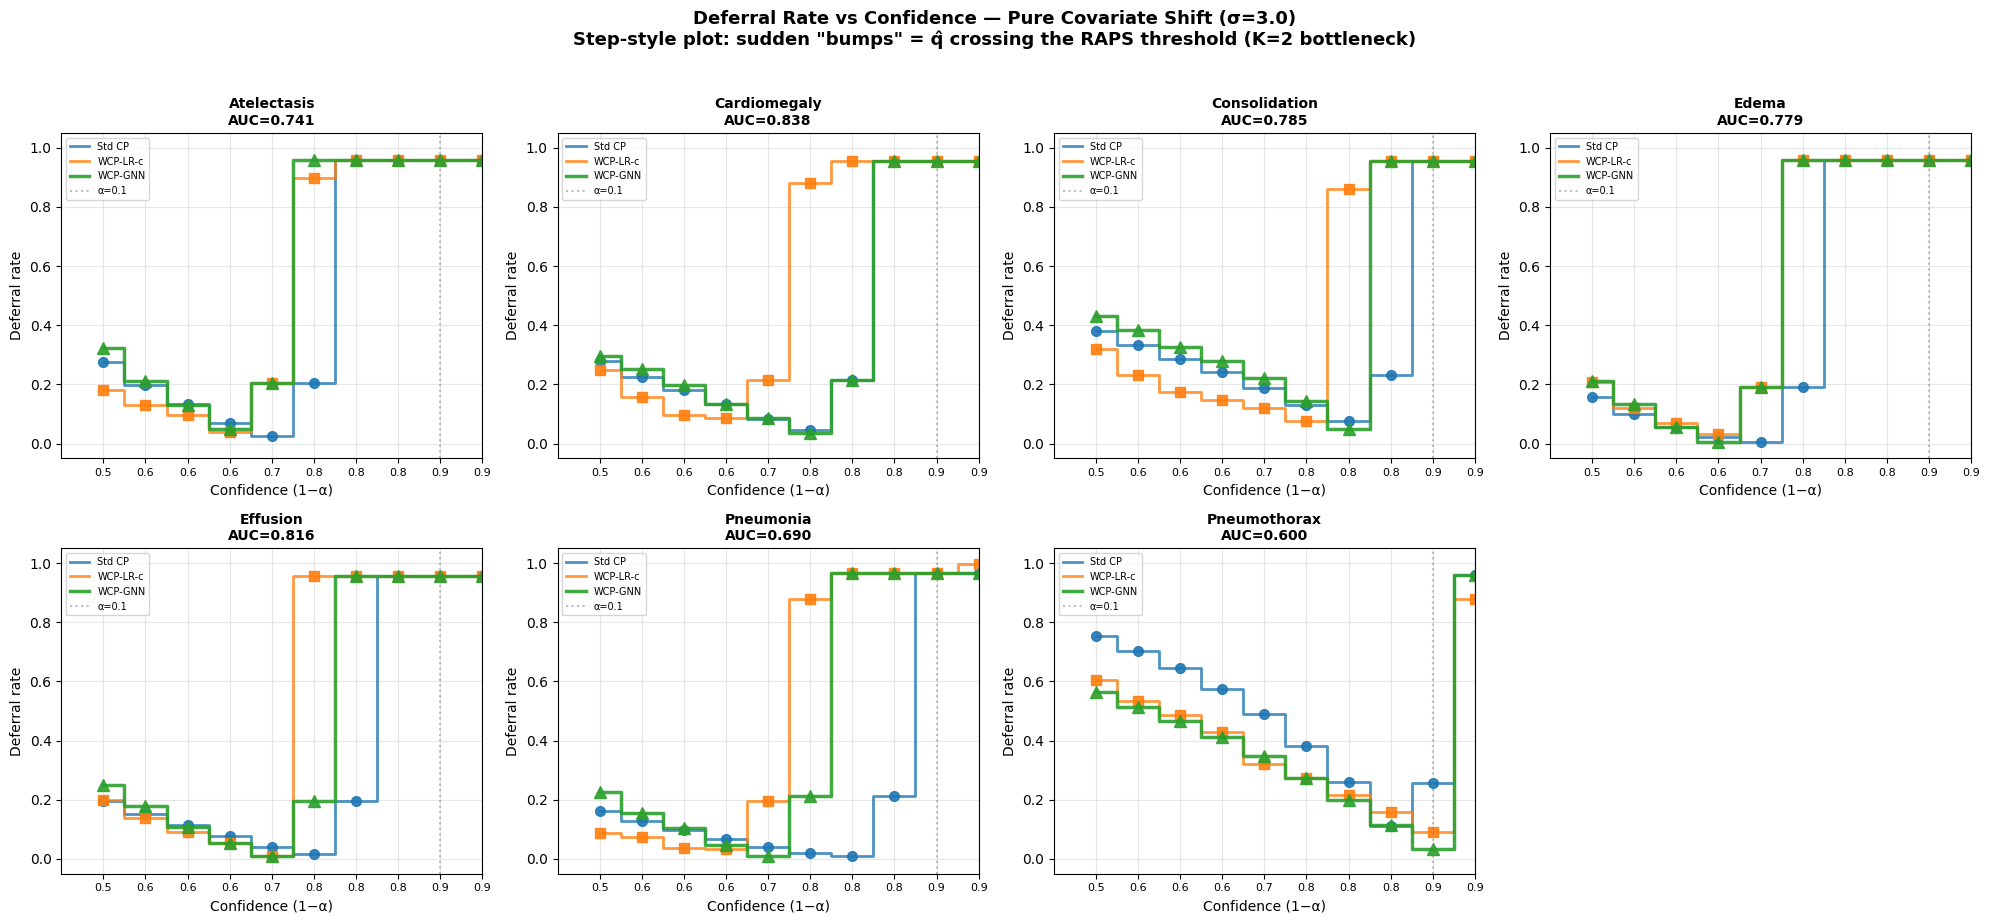

In [11]:
conf_lvls = 1 - ALPHAS

fig, axes = plt.subplots(2, 4, figsize=(20, 9), sharey=False)
axes_flat = axes.flatten()

for i, path in enumerate(COMMON_PATHOLOGIES):
    ax = axes_flat[i]
    r  = all_results[path]

    # Step-style lines + large markers to make discrete α "bumps" visible
    ax.step(conf_lvls, [x.deferral_rate for x in r['std_cp']],
            where='mid', lw=2.0, alpha=0.8, color='#1f77b4', label='Std CP')
    ax.plot(conf_lvls, [x.deferral_rate for x in r['std_cp']],
            'o', ms=7, color='#1f77b4', alpha=0.9)

    ax.step(conf_lvls, [x.deferral_rate for x in r['wcp_lr']],
            where='mid', lw=2.0, alpha=0.8, color='#ff7f0e', label='WCP-LR-c')
    ax.plot(conf_lvls, [x.deferral_rate for x in r['wcp_lr']],
            's', ms=7, color='#ff7f0e', alpha=0.9)

    ax.step(conf_lvls, [x.deferral_rate for x in r['wcp_gnn']],
            where='mid', lw=2.5, alpha=0.9, color='#2ca02c', label='WCP-GNN')
    ax.plot(conf_lvls, [x.deferral_rate for x in r['wcp_gnn']],
            '^', ms=8, color='#2ca02c', alpha=0.9)

    ax.axvline(1 - ALPHA, color='gray', linestyle=':', alpha=0.5, label=f'α={ALPHA}')
    ax.set_title(f'{path}\nAUC={r["test_auc"]:.3f}', fontsize=10, fontweight='bold')
    ax.set_xlabel('Confidence (1−α)'); ax.set_ylabel('Deferral rate')
    ax.set_xlim(0.45, 0.95); ax.set_ylim(-0.05, 1.05)
    ax.set_xticks(conf_lvls); ax.set_xticklabels([f'{c:.1f}' for c in conf_lvls], fontsize=8)
    ax.legend(fontsize=7)

axes_flat[-1].axis('off')
plt.suptitle(f'Deferral Rate vs Confidence — Pure Covariate Shift (σ={SIGMA})\n'
             'Step-style plot: sudden "bumps" = q̂ crossing the RAPS threshold (K=2 bottleneck)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 11. Coverage Rate vs α

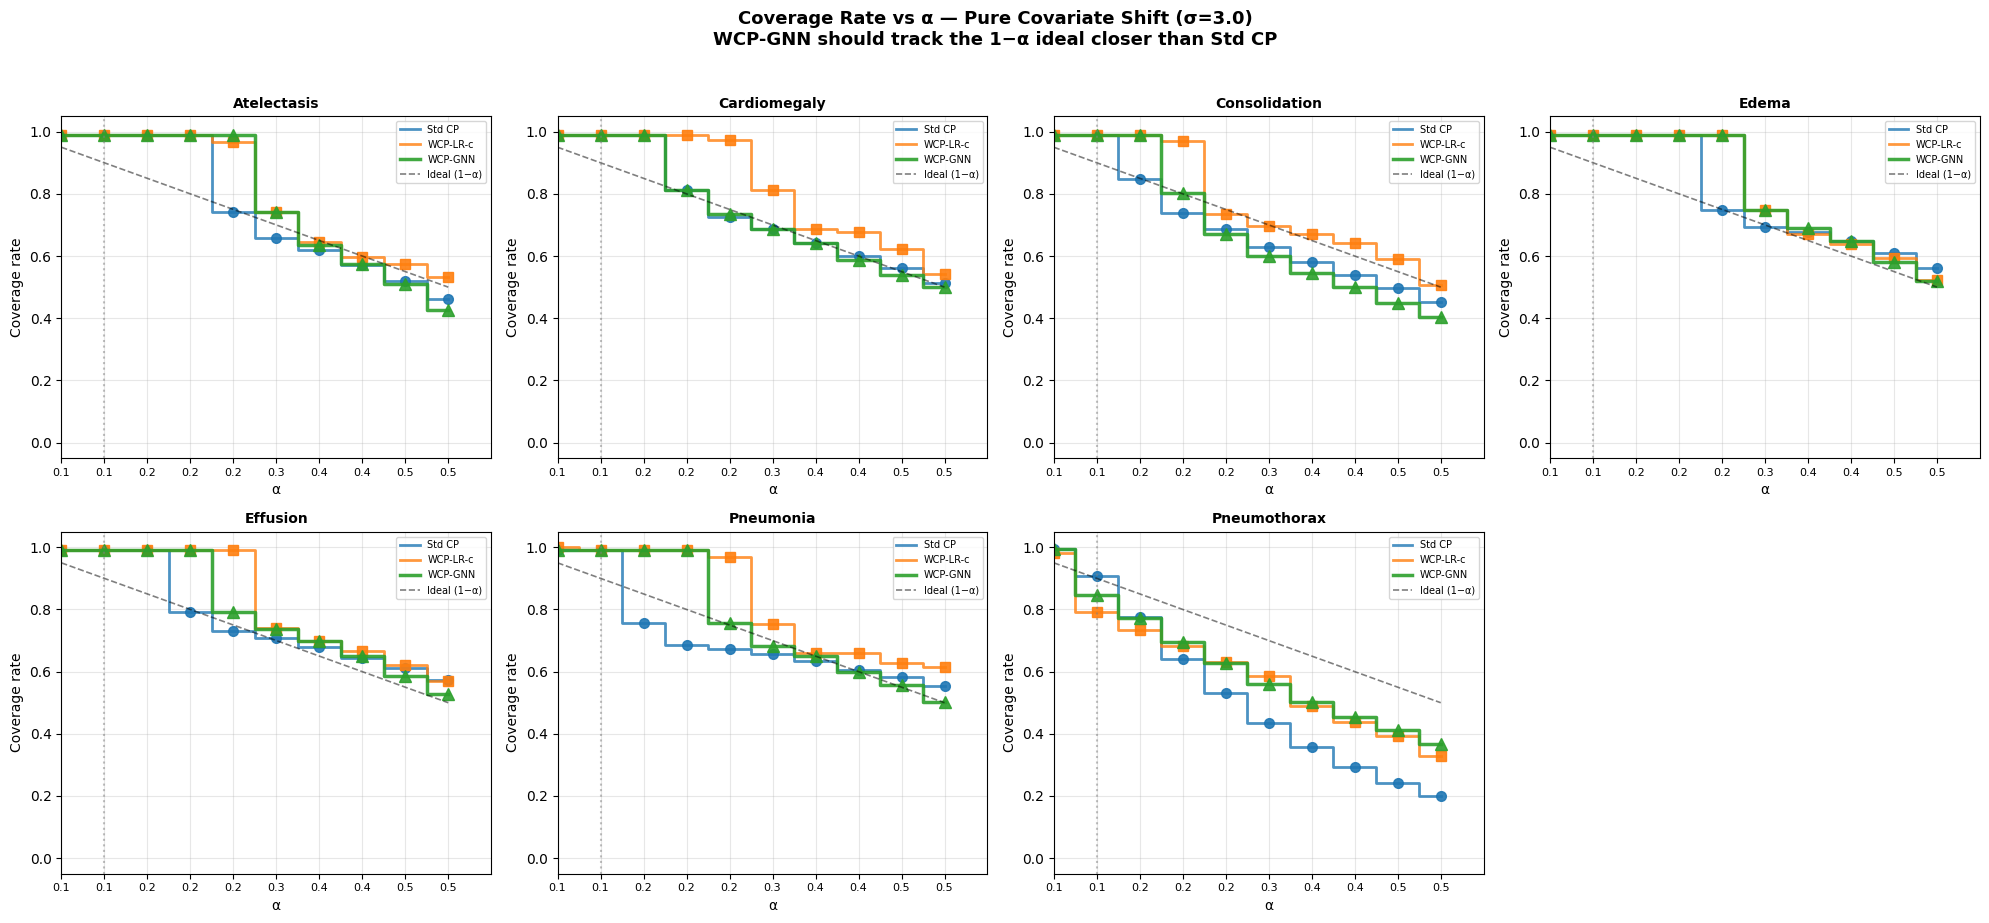

In [12]:
fig, axes = plt.subplots(2, 4, figsize=(20, 9), sharey=False)
axes_flat = axes.flatten()

for i, path in enumerate(COMMON_PATHOLOGIES):
    ax = axes_flat[i]
    r  = all_results[path]

    ax.step(ALPHAS, [x.coverage_rate for x in r['std_cp']],
            where='mid', lw=2.0, alpha=0.8, color='#1f77b4', label='Std CP')
    ax.plot(ALPHAS, [x.coverage_rate for x in r['std_cp']],
            'o', ms=7, color='#1f77b4', alpha=0.9)

    ax.step(ALPHAS, [x.coverage_rate for x in r['wcp_lr']],
            where='mid', lw=2.0, alpha=0.8, color='#ff7f0e', label='WCP-LR-c')
    ax.plot(ALPHAS, [x.coverage_rate for x in r['wcp_lr']],
            's', ms=7, color='#ff7f0e', alpha=0.9)

    ax.step(ALPHAS, [x.coverage_rate for x in r['wcp_gnn']],
            where='mid', lw=2.5, alpha=0.9, color='#2ca02c', label='WCP-GNN')
    ax.plot(ALPHAS, [x.coverage_rate for x in r['wcp_gnn']],
            '^', ms=8, color='#2ca02c', alpha=0.9)

    ax.plot(ALPHAS, 1 - ALPHAS, 'k--', lw=1.2, alpha=0.5, label='Ideal (1−α)')

    ax.axvline(ALPHA, color='gray', linestyle=':', alpha=0.5)
    ax.set_title(path, fontsize=10, fontweight='bold')
    ax.set_xlabel('α'); ax.set_ylabel('Coverage rate')
    ax.set_xlim(0.05, 0.55); ax.set_ylim(-0.05, 1.05)
    ax.set_xticks(ALPHAS); ax.set_xticklabels([f'{a:.1f}' for a in ALPHAS], fontsize=8)
    ax.legend(fontsize=7)

axes_flat[-1].axis('off')
plt.suptitle(f'Coverage Rate vs α — Pure Covariate Shift (σ={SIGMA})\n'
             'WCP-GNN should track the 1−α ideal closer than Std CP',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 12. Accuracy-Rejection Curves

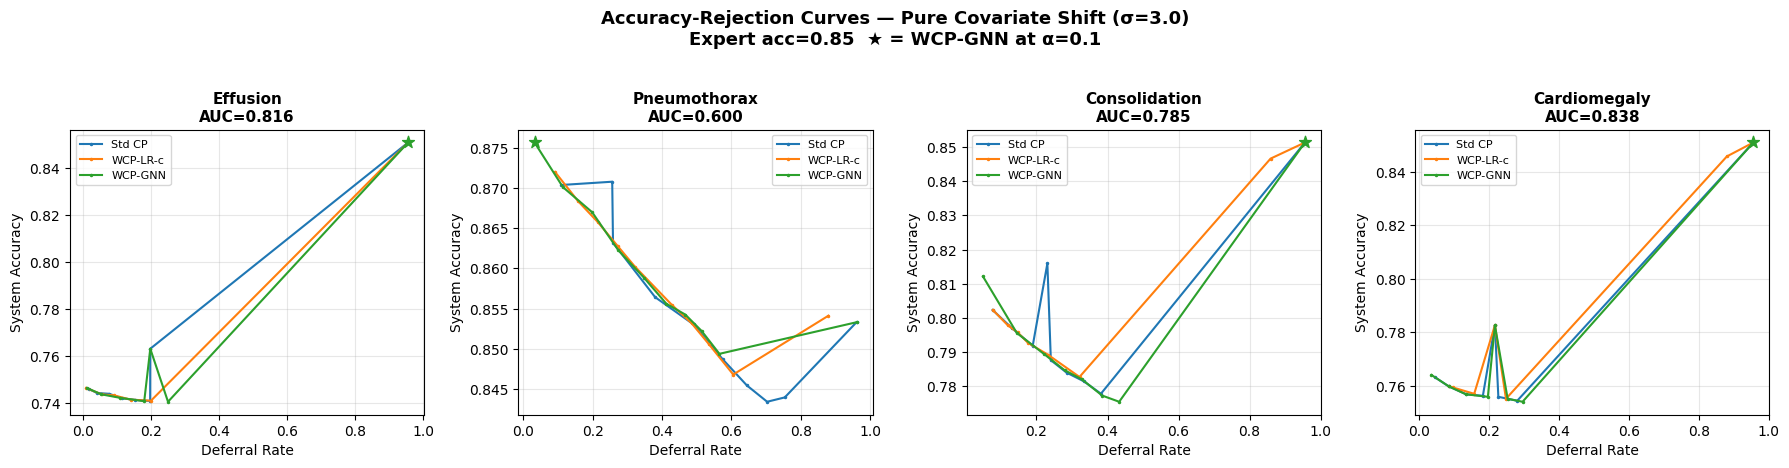

In [13]:
highlight = ['Effusion', 'Pneumothorax', 'Consolidation', 'Cardiomegaly']

fig, axes = plt.subplots(1, 4, figsize=(18, 4.5))
colors = {'Std CP': '#1f77b4', 'WCP-LR-c': '#ff7f0e', 'WCP-GNN': '#2ca02c'}

for ax, path in zip(axes, highlight):
    r = all_results[path]
    for label, res_list in [('Std CP',   r['std_cp']),
                             ('WCP-LR-c', r['wcp_lr']),
                             ('WCP-GNN',  r['wcp_gnn'])]:
        dr    = np.array([x.deferral_rate    for x in res_list])
        sa    = np.array([x.system_accuracy  for x in res_list])
        order = np.argsort(dr)
        ax.plot(dr[order], sa[order], '.-', lw=1.5, ms=3, label=label, color=colors[label])

    # Mark α=0.10 operating point for WCP-GNN
    pt = at_alpha(r['wcp_gnn'])
    ax.scatter([pt.deferral_rate], [pt.system_accuracy], s=80, zorder=5,
               color='#2ca02c', marker='*')

    ax.set_title(f'{path}\nAUC={r["test_auc"]:.3f}', fontsize=11, fontweight='bold')
    ax.set_xlabel('Deferral Rate'); ax.set_ylabel('System Accuracy')
    ax.legend(fontsize=8)

plt.suptitle(f'Accuracy-Rejection Curves — Pure Covariate Shift (σ={SIGMA})\n'
             f'Expert acc={EXPERT}  ★ = WCP-GNN at α={ALPHA}',
             fontsize=13, fontweight='bold', y=1.03)
plt.tight_layout()
plt.show()

## Extended Analysis (A0–A4)

| Analysis | Question |
|----------|----------|
| **A0 Setup** | Collect raw prediction sets at α=0.10 |
| **A1 Coverage Validity** | Is empirical coverage ≥ 1−α under pure shift? |
| **A2 Set Size Breakdown** | |C|=0/1/2 fractions — does GNN-DRE produce more singletons? |
| **A3 Singleton Error Rate** | FNR/FPR on non-deferred samples |
| **A4 q̂ Stability** | Does higher ESS yield smoother weighted CDFs? |

### A0. Prediction Set Collection at α = 0.10

In [14]:
ALPHA_FIXED = 0.10
detail = {}

for pathology in COMMON_PATHOLOGIES:
    k = COMMON_PATHOLOGIES.index(pathology)

    c_mask = ~np.isnan(Y_cal[:, k])
    t_mask = ~np.isnan(Y_test[:, k])
    Xc, yc = X_cal[c_mask],  Y_cal[c_mask, k].astype(int)
    Xt, yt = X_test[t_mask], Y_test[t_mask, k].astype(int)

    tr_mask = ~np.isnan(Y_train[:, k])
    clf_p   = LogisticRegression(solver='lbfgs', max_iter=1000, C=1.0, random_state=SEED)
    clf_p.fit(X_train[tr_mask], Y_train[tr_mask, k].astype(int))
    cal_lg  = binary_logits(clf_p, Xc)
    test_lg = binary_logits(clf_p, Xt)

    wc_lr, wt_lr   = w_cal_lr[c_mask],  w_test_lr[t_mask]
    wc_gnn, wt_gnn = w_cal_gnn[c_mask], w_test_gnn[t_mask]

    # Standard CP
    cp_std   = ConformalPredictor(penalty=0.1, kreg=1, randomized=False)
    q_std    = cp_std.calibrate(cal_lg, yc, alpha=ALPHA_FIXED)
    ps_std   = cp_std.predict(test_lg)
    cal_scores = cp_std.cal_scores

    # WCP-LR-c
    wcp_lr_  = WeightedConformalPredictor(penalty=0.1, kreg=1, randomized=False)
    wcp_lr_.calibrate(cal_lg, yc, wc_lr)
    ps_lr    = wcp_lr_.predict(test_lg, wt_lr, alpha=ALPHA_FIXED)

    # WCP-GNN
    wcp_gnn_ = WeightedConformalPredictor(penalty=0.1, kreg=1, randomized=False)
    wcp_gnn_.calibrate(cal_lg, yc, wc_gnn)
    ps_gnn   = wcp_gnn_.predict(test_lg, wt_gnn, alpha=ALPHA_FIXED)

    detail[pathology] = dict(
        ps_std=ps_std, ps_lr=ps_lr, ps_gnn=ps_gnn,
        yt=yt, test_lg=test_lg,
        cal_scores=cal_scores,
        wc_lr=wc_lr, wc_gnn=wc_gnn,
        wt_lr=wt_lr, wt_gnn=wt_gnn,
        q_std=q_std,
    )

print(f'Prediction sets collected for {len(detail)} pathologies at α={ALPHA_FIXED}')
print(f'\n{"Pathology":<16}  {"n_test":>6}  '
      f'{"Std |C|=0/1/2":>18}  {"LR-c |C|=0/1/2":>18}  {"GNN |C|=0/1/2":>18}')
print('-' * 84)
for path, d in detail.items():
    def fmtsz(ps):
        s = ps.sum(axis=1)
        return f'{(s==0).mean():.2f}/{(s==1).mean():.2f}/{(s==2).mean():.2f}'
    print(f'{path:<16}  {len(d["yt"]):>6}  '
          f'{fmtsz(d["ps_std"]):>18}  {fmtsz(d["ps_lr"]):>18}  {fmtsz(d["ps_gnn"]):>18}')

Prediction sets collected for 7 pathologies at α=0.1

Pathology         n_test       Std |C|=0/1/2      LR-c |C|=0/1/2       GNN |C|=0/1/2
------------------------------------------------------------------------------------
Atelectasis         5376      0.00/0.04/0.96      0.00/0.04/0.96      0.00/0.04/0.96
Cardiomegaly        5377      0.00/0.04/0.96      0.00/0.04/0.96      0.00/0.04/0.96
Consolidation       5515      0.00/0.04/0.96      0.00/0.04/0.96      0.00/0.04/0.96
Edema               7122      0.00/0.04/0.96      0.00/0.04/0.96      0.00/0.04/0.96
Effusion            8840      0.00/0.05/0.95      0.00/0.05/0.95      0.00/0.05/0.95
Pneumonia           3451      0.00/0.04/0.96      0.00/0.04/0.96      0.00/0.04/0.96
Pneumothorax        7390      0.00/0.74/0.26      0.09/0.91/0.00      0.03/0.97/0.00


### A1. Empirical Coverage Validity

Under pure covariate shift (no label shift), WCP with good density ratio weights should
restore the 1−α coverage guarantee. Does GNN-DRE's higher ESS produce coverage closer
to the ideal 1−α line than LR-c?

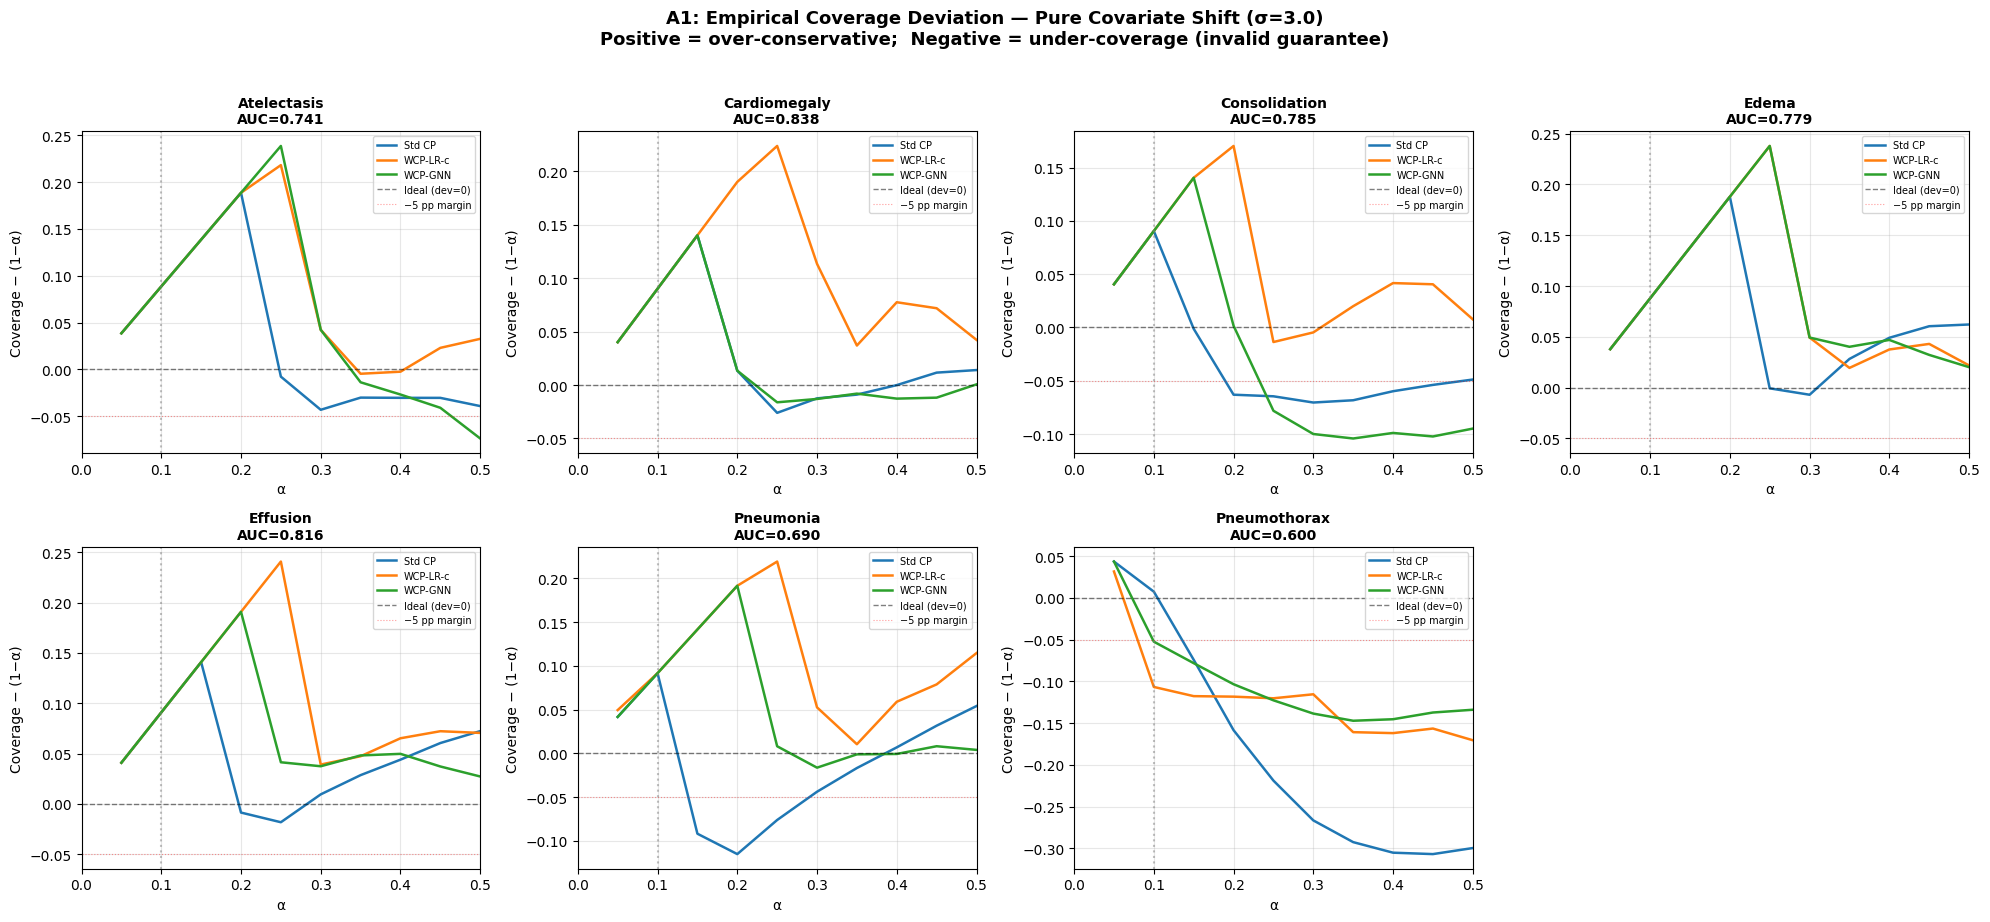


A1: Coverage validity at α=0.1  (target ≥ 0.90):
Pathology        |   Std cov     dev |  LR-c cov     dev |   GNN cov     dev
----------------------------------------------------------------------------
Atelectasis      |     0.989  +0.089   |     0.989  +0.089   |     0.989  +0.089  
Cardiomegaly     |     0.990  +0.090   |     0.990  +0.090   |     0.990  +0.090  
Consolidation    |     0.991  +0.091   |     0.991  +0.091   |     0.991  +0.091  
Edema            |     0.988  +0.088   |     0.988  +0.088   |     0.988  +0.088  
Effusion         |     0.991  +0.091   |     0.991  +0.091   |     0.991  +0.091  
Pneumonia        |     0.992  +0.092   |     0.992  +0.092   |     0.992  +0.092  
Pneumothorax     |     0.908  +0.008   |     0.793  -0.107 ✗ |     0.848  -0.052 ✗

Under-coverage count (cov < 0.90) at α=0.1:
  Std CP        0/7  ✓ all valid
  WCP-LR-c      1/7  ← under-covered
  WCP-GNN       1/7  ← under-covered


In [15]:
fig, axes = plt.subplots(2, 4, figsize=(20, 9), sharey=False)
axes_flat = axes.flatten()

under_cov = {'Std CP': 0, 'WCP-LR-c': 0, 'WCP-GNN': 0}
target_cov = 1 - ALPHA

for i, path in enumerate(COMMON_PATHOLOGIES):
    ax = axes_flat[i]
    r  = all_results[path]

    for label, res_list, col in [
        ('Std CP',   r['std_cp'],  '#1f77b4'),
        ('WCP-LR-c', r['wcp_lr'],  '#ff7f0e'),
        ('WCP-GNN',  r['wcp_gnn'], '#2ca02c'),
    ]:
        alphas_arr = np.array([x.alpha_or_threshold for x in res_list])
        covs       = np.array([x.coverage_rate      for x in res_list])
        deviation  = covs - (1 - alphas_arr)
        ax.plot(alphas_arr, deviation, lw=1.8, label=label, color=col)

        pt = at_alpha(res_list)
        if pt.coverage_rate < target_cov:
            under_cov[label] += 1

    ax.axhline(0,     color='black', lw=1.0, linestyle='--', alpha=0.5, label='Ideal (dev=0)')
    ax.axhline(-0.05, color='red',   lw=0.8, linestyle=':', alpha=0.4, label='−5 pp margin')
    ax.axvline(ALPHA, color='gray',  linestyle=':', alpha=0.5)
    ax.set_title(f'{path}\nAUC={r["test_auc"]:.3f}', fontsize=10, fontweight='bold')
    ax.set_xlabel('α'); ax.set_ylabel('Coverage − (1−α)')
    ax.set_xlim(0, 0.5)
    ax.legend(fontsize=7)

axes_flat[-1].axis('off')
plt.suptitle(f'A1: Empirical Coverage Deviation — Pure Covariate Shift (σ={SIGMA})\n'
             'Positive = over-conservative;  Negative = under-coverage (invalid guarantee)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f'\nA1: Coverage validity at α={ALPHA}  (target ≥ {target_cov:.2f}):')
hdr = (f"{'Pathology':<16} | "
       f"{'Std cov':>9} {'dev':>7} | "
       f"{'LR-c cov':>9} {'dev':>7} | "
       f"{'GNN cov':>9} {'dev':>7}")
print(hdr); print('-' * len(hdr))
for path in COMMON_PATHOLOGIES:
    r = all_results[path]
    std_c = at_alpha(r['std_cp']).coverage_rate
    lr_c  = at_alpha(r['wcp_lr']).coverage_rate
    gnn_c = at_alpha(r['wcp_gnn']).coverage_rate
    def flag(c): return ' ✗' if c < target_cov else '  '
    print(f'{path:<16} | '
          f'{std_c:>9.3f} {std_c-target_cov:>+7.3f}{flag(std_c)} | '
          f'{lr_c:>9.3f} {lr_c-target_cov:>+7.3f}{flag(lr_c)} | '
          f'{gnn_c:>9.3f} {gnn_c-target_cov:>+7.3f}{flag(gnn_c)}')

print(f'\nUnder-coverage count (cov < {target_cov:.2f}) at α={ALPHA}:')
for method, cnt in under_cov.items():
    print(f'  {method:<12}  {cnt}/7  {"← under-covered" if cnt > 0 else "✓ all valid"}')

### A2. Prediction Set Size Breakdown

For binary K=2 RAPS, prediction sets are |C|=0 (empty), |C|=1 (singleton/decide), or
|C|=2 (full set/defer). Under pure shift (no label shift), expect more singletons than
under compound NIH shift.

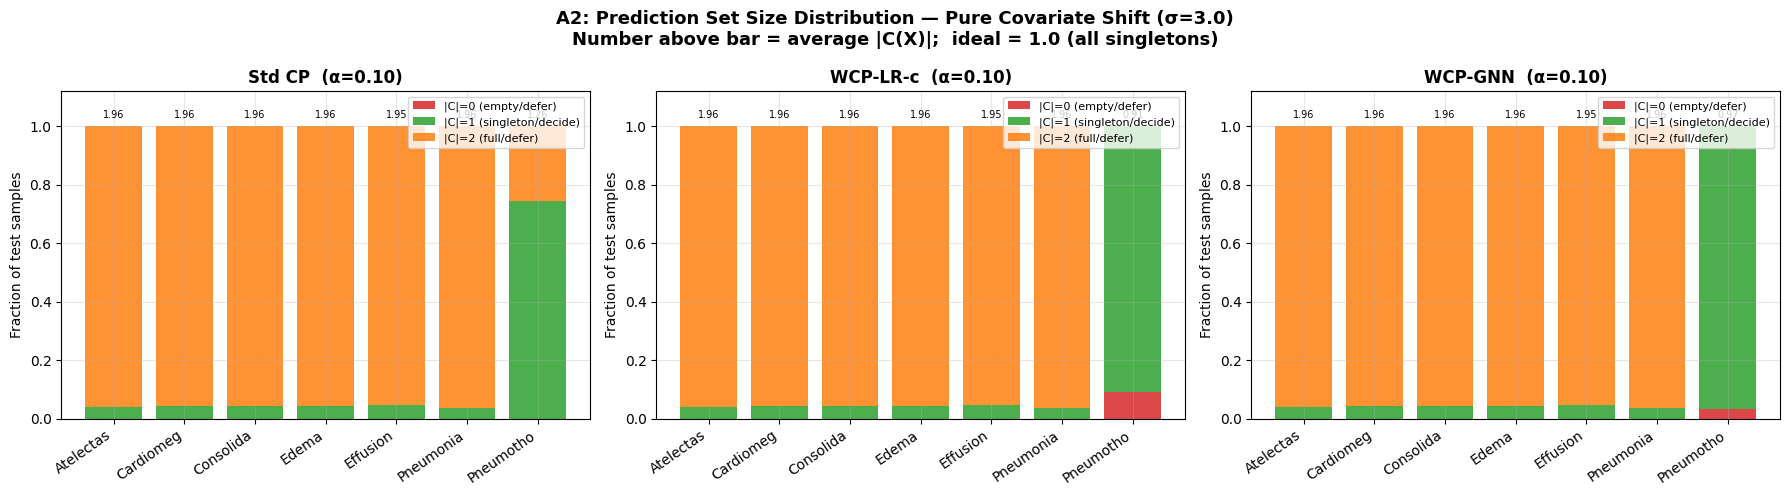


A2: Average Set Size and Singleton Rate at α=0.1:
Pathology        |  Std avg     f1 | LR-c avg     f1 |  GNN avg     f1
----------------------------------------------------------------------
Atelectasis      |    1.959  0.041 |    1.959  0.041 |    1.959  0.041
Cardiomegaly     |    1.956  0.044 |    1.956  0.044 |    1.956  0.044
Consolidation    |    1.956  0.044 |    1.956  0.044 |    1.956  0.044
Edema            |    1.959  0.041 |    1.959  0.041 |    1.959  0.041
Effusion         |    1.955  0.045 |    1.955  0.045 |    1.955  0.045
Pneumonia        |    1.965  0.035 |    1.965  0.035 |    1.965  0.035
Pneumothorax     |    1.257  0.743 |    0.908  0.908 |    0.967  0.967

Mean avg set size:   Std=1.858  LR-c=1.808  GNN=1.817
Mean singleton rate: Std=0.142   LR-c=0.166   GNN=0.174


In [16]:
set_size_data = {}
for path in COMMON_PATHOLOGIES:
    d = detail[path]
    entry = {}
    for label, ps in [('Std CP', d['ps_std']),
                      ('WCP-LR-c', d['ps_lr']),
                      ('WCP-GNN',  d['ps_gnn'])]:
        sizes = ps.sum(axis=1)
        entry[label] = {
            'frac0': float((sizes == 0).mean()),
            'frac1': float((sizes == 1).mean()),
            'frac2': float((sizes == 2).mean()),
            'avg':   float(sizes.mean()),
        }
    set_size_data[path] = entry

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
method_list = [('Std CP', '#1f77b4'), ('WCP-LR-c', '#ff7f0e'), ('WCP-GNN', '#2ca02c')]
x = np.arange(len(COMMON_PATHOLOGIES))

for m_i, (method, base_col) in enumerate(method_list):
    ax = axes[m_i]
    f0 = np.array([set_size_data[p][method]['frac0'] for p in COMMON_PATHOLOGIES])
    f1 = np.array([set_size_data[p][method]['frac1'] for p in COMMON_PATHOLOGIES])
    f2 = np.array([set_size_data[p][method]['frac2'] for p in COMMON_PATHOLOGIES])

    ax.bar(x, f0,     color='#d62728', alpha=0.85, label='|C|=0 (empty/defer)')
    ax.bar(x, f1, bottom=f0,     color='#2ca02c', alpha=0.85, label='|C|=1 (singleton/decide)')
    ax.bar(x, f2, bottom=f0+f1, color='#ff7f0e', alpha=0.85, label='|C|=2 (full/defer)')

    avg = np.array([set_size_data[p][method]['avg'] for p in COMMON_PATHOLOGIES])
    for xi, av in zip(x, avg):
        ax.text(xi, 1.02, f'{av:.2f}', ha='center', va='bottom', fontsize=7)

    ax.set_xticks(x)
    ax.set_xticklabels([p[:9] for p in COMMON_PATHOLOGIES], rotation=35, ha='right')
    ax.set_ylabel('Fraction of test samples')
    ax.set_title(f'{method}  (α=0.10)', fontsize=12, fontweight='bold')
    ax.legend(fontsize=8, loc='upper right')
    ax.set_ylim(0, 1.12)

plt.suptitle(f'A2: Prediction Set Size Distribution — Pure Covariate Shift (σ={SIGMA})\n'
             'Number above bar = average |C(X)|;  ideal = 1.0 (all singletons)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'\nA2: Average Set Size and Singleton Rate at α={ALPHA}:')
hdr = (f"{'Pathology':<16} | "
       f"{'Std avg':>8} {'f1':>6} | "
       f"{'LR-c avg':>8} {'f1':>6} | "
       f"{'GNN avg':>8} {'f1':>6}")
print(hdr); print('-' * len(hdr))
for path in COMMON_PATHOLOGIES:
    s = set_size_data[path]
    print(f'{path:<16} | '
          f'{s["Std CP"]["avg"]:>8.3f} {s["Std CP"]["frac1"]:>6.3f} | '
          f'{s["WCP-LR-c"]["avg"]:>8.3f} {s["WCP-LR-c"]["frac1"]:>6.3f} | '
          f'{s["WCP-GNN"]["avg"]:>8.3f} {s["WCP-GNN"]["frac1"]:>6.3f}')

means = {m: np.mean([set_size_data[p][m]['avg']   for p in COMMON_PATHOLOGIES])
         for m in ['Std CP', 'WCP-LR-c', 'WCP-GNN']}
f1s   = {m: np.mean([set_size_data[p][m]['frac1'] for p in COMMON_PATHOLOGIES])
         for m in ['Std CP', 'WCP-LR-c', 'WCP-GNN']}
print(f'\nMean avg set size:   Std={means["Std CP"]:.3f}  LR-c={means["WCP-LR-c"]:.3f}  GNN={means["WCP-GNN"]:.3f}')
print(f'Mean singleton rate: Std={f1s["Std CP"]:.3f}   LR-c={f1s["WCP-LR-c"]:.3f}   GNN={f1s["WCP-GNN"]:.3f}')

### A3. Singleton Error Rate (FNR / FPR on Non-Deferred Samples)

When |C(X)| = 1, the system makes an autonomous decision. Under pure covariate shift
(no label shift), we expect singleton error rates to be better calibrated.

A3: Singleton Error Rate at α=0.1  (pure covariate shift σ=3.0)
FNR/FPR computed only on non-deferred samples (|C(X)|=1)
Pathology         n_pos |   Std n_single    FNR    FPR |  LR-c n_single    FNR    FPR |   GNN n_single    FNR    FPR
--------------------------------------------------------------------------------------------------------------------
Atelectasis        2558 |       219 (4%)  0.150  0.434 |       219 (4%)  0.150  0.434 |       219 (4%)  0.150  0.434
Cardiomegaly       1876 |       239 (4%)  0.175  0.245 |       239 (4%)  0.175  0.245 |       239 (4%)  0.175  0.245
Consolidation      1102 |       243 (4%)  0.672  0.070 |       243 (4%)  0.672  0.070 |       243 (4%)  0.672  0.070
Edema              3042 |       295 (4%)  0.147  0.404 |       295 (4%)  0.147  0.404 |       295 (4%)  0.147  0.404
Effusion           4254 |       399 (5%)  0.133  0.265 |       399 (5%)  0.133  0.265 |       399 (5%)  0.133  0.265
Pneumonia           541 |       122 (4%)  0.471  0.200 |    

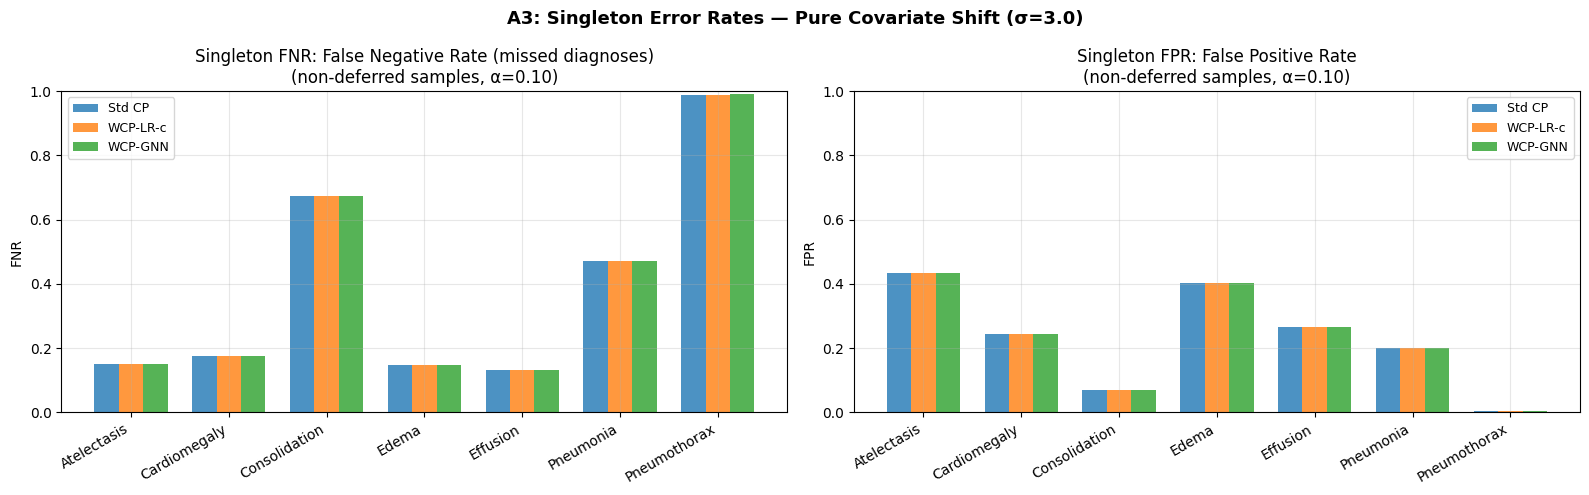

In [17]:
singleton_rows = []

for path in COMMON_PATHOLOGIES:
    d  = detail[path]
    yt = d['yt']
    row = {'Pathology': path, 'n_test': len(yt), 'n_pos': int(yt.sum())}

    for label, ps in [('Std CP',   d['ps_std']),
                      ('WCP-LR-c', d['ps_lr']),
                      ('WCP-GNN',  d['ps_gnn'])]:
        sizes         = ps.sum(axis=1)
        singleton_idx = np.where(sizes == 1)[0]
        n_single      = len(singleton_idx)

        if n_single == 0:
            row[f'{label} n%'] = '0 (0%)'
            row[f'{label} FNR'] = float('nan')
            row[f'{label} FPR'] = float('nan')
            continue

        preds_s = ps[singleton_idx].argmax(axis=1)
        y_s     = yt[singleton_idx]
        pos     = y_s == 1
        neg     = y_s == 0

        fnr = float((preds_s[pos] == 0).mean()) if pos.sum() > 0 else float('nan')
        fpr = float((preds_s[neg] == 1).mean()) if neg.sum() > 0 else float('nan')
        row[f'{label} n%']  = f'{n_single} ({100*n_single/len(yt):.0f}%)'
        row[f'{label} FNR'] = round(fnr, 4)
        row[f'{label} FPR'] = round(fpr, 4)

    singleton_rows.append(row)

df_single = pd.DataFrame(singleton_rows).set_index('Pathology')

print(f'A3: Singleton Error Rate at α={ALPHA}  (pure covariate shift σ={SIGMA})')
print('FNR/FPR computed only on non-deferred samples (|C(X)|=1)')
print('=' * 90)
hdr = (f"{'Pathology':<16} {'n_pos':>6} | "
       f"{'Std n_single':>14} {'FNR':>6} {'FPR':>6} | "
       f"{'LR-c n_single':>14} {'FNR':>6} {'FPR':>6} | "
       f"{'GNN n_single':>14} {'FNR':>6} {'FPR':>6}")
print(hdr); print('-' * len(hdr))
for path in COMMON_PATHOLOGIES:
    r_ = df_single.loc[path]
    def fmt(m):
        n   = r_.get(f'{m} n%', '—')
        fnr = r_.get(f'{m} FNR', float('nan'))
        fpr = r_.get(f'{m} FPR', float('nan'))
        fnr_s = f'{fnr:.3f}' if not np.isnan(fnr) else '  n/a'
        fpr_s = f'{fpr:.3f}' if not np.isnan(fpr) else '  n/a'
        return f'{str(n):>14} {fnr_s:>6} {fpr_s:>6}'
    print(f'{path:<16} {r_["n_pos"]:>6} | {fmt("Std CP")} | {fmt("WCP-LR-c")} | {fmt("WCP-GNN")}')

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
methods_vis = [('Std CP', '#1f77b4'), ('WCP-LR-c', '#ff7f0e'), ('WCP-GNN', '#2ca02c')]
x = np.arange(len(COMMON_PATHOLOGIES))
width = 0.25

for ax, metric in zip(axes, ['FNR', 'FPR']):
    for m_i, (method, col) in enumerate(methods_vis):
        vals = [float(df_single.loc[p].get(f'{method} {metric}', float('nan')))
                for p in COMMON_PATHOLOGIES]
        vals = [v if not np.isnan(v) else 0 for v in vals]
        ax.bar(x + (m_i - 1) * width, vals, width, label=method, color=col, alpha=0.8)
    ax.set_xticks(x)
    ax.set_xticklabels(COMMON_PATHOLOGIES, rotation=30, ha='right')
    ax.set_ylabel(metric)
    label_full = 'False Negative Rate (missed diagnoses)' if metric == 'FNR' else 'False Positive Rate'
    ax.set_title(f'Singleton {metric}: {label_full}\n(non-deferred samples, α=0.10)')
    ax.legend(fontsize=9); ax.set_ylim(0, 1.0)

plt.suptitle(f'A3: Singleton Error Rates — Pure Covariate Shift (σ={SIGMA})',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### A4. Calibration Quantile Stability (q̂)

Under pure covariate shift, higher ESS (GNN-DRE) should produce a smoother weighted
empirical CDF, leading to a more stable q̂ threshold than LR-c (lower ESS).

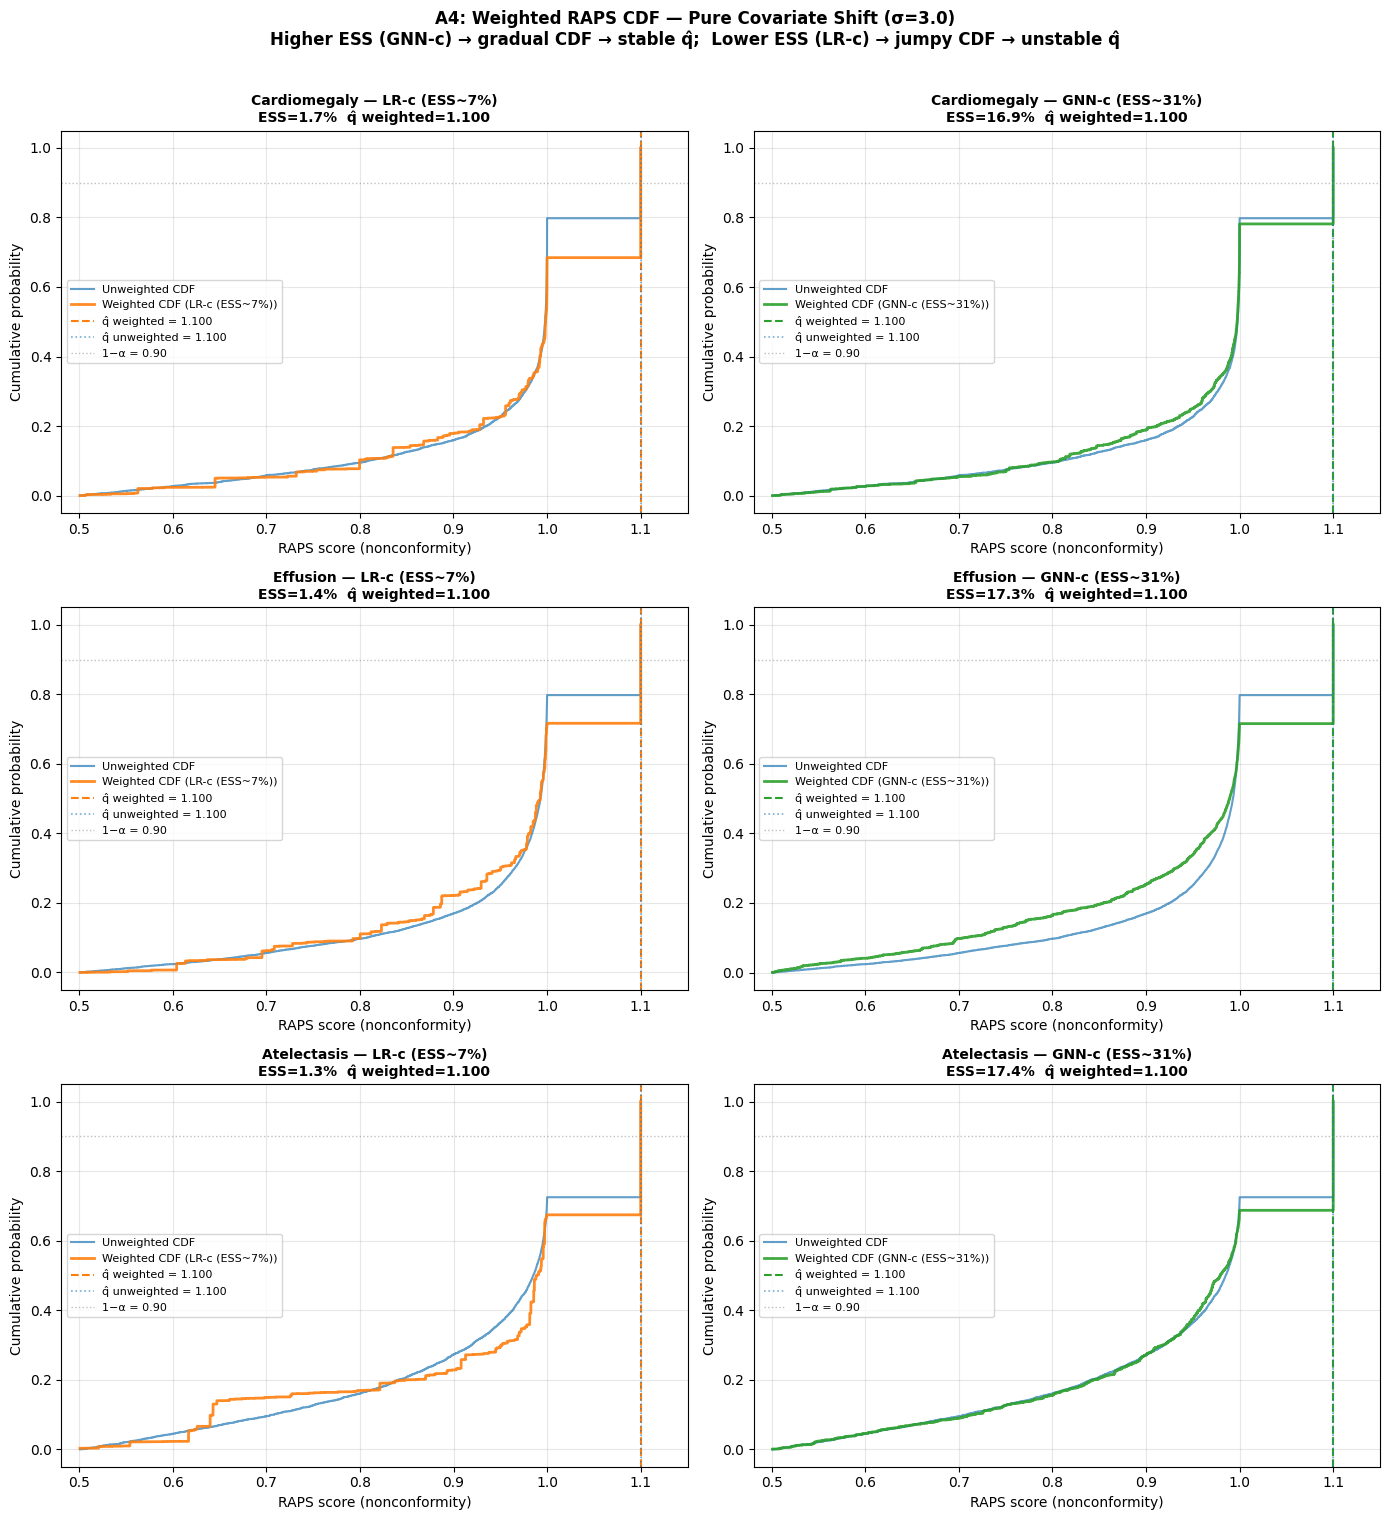


q̂ at median test weight vs unweighted q̂  (α=0.1):
Pathology           Std q̂    LR-c q̂     GNN q̂ LR-c defer  GNN defer
----------------------------------------------------------------------
Atelectasis          1.100      1.100      1.100     95.9%      95.9%
Cardiomegaly         1.100      1.100      1.100     95.6%      95.6%
Consolidation        1.100      1.100      1.100     95.6%      95.6%
Edema                1.100      1.100      1.100     95.9%      95.9%
Effusion             1.100      1.100      1.100     95.5%      95.5%
Pneumonia            1.100      1.100      1.100     96.5%      96.5%
Pneumothorax         1.100      1.000      1.000      9.2%       3.3%


In [18]:
focus_paths = ['Cardiomegaly', 'Effusion', 'Atelectasis']
fig, axes = plt.subplots(len(focus_paths), 2, figsize=(14, 5 * len(focus_paths)))

for row_i, path in enumerate(focus_paths):
    d      = detail[path]
    scores = d['cal_scores']

    for col_i, (dre_name, weights, col) in enumerate([
        ('LR-c (ESS~7%)',   d['wc_lr'],  '#ff7f0e'),
        ('GNN-c (ESS~31%)', d['wc_gnn'], '#2ca02c'),
    ]):
        ax = axes[row_i, col_i]

        sort_idx = np.argsort(scores)
        s_sorted = scores[sort_idx]
        w_sorted = weights[sort_idx]
        w_norm   = w_sorted / w_sorted.sum()
        cum_w    = np.cumsum(w_norm)
        cum_uw   = np.arange(1, len(s_sorted) + 1) / len(s_sorted)

        ax.step(s_sorted, cum_uw, where='post', color='#1f77b4', lw=1.5,
                alpha=0.7, label='Unweighted CDF')
        ax.step(s_sorted, cum_w,  where='post', color=col, lw=2.0,
                alpha=0.9, label=f'Weighted CDF ({dre_name})')

        target  = 1 - ALPHA
        idx_q   = int(np.searchsorted(cum_w, target, side='left'))
        idx_q   = min(idx_q, len(s_sorted) - 1)
        q_hat_w = s_sorted[idx_q]

        ax.axvline(q_hat_w, color=col, linestyle='--', lw=1.5,
                   label=f'q̂ weighted = {q_hat_w:.3f}')
        ax.axvline(d['q_std'], color='#1f77b4', linestyle=':', lw=1.2,
                   alpha=0.6, label=f'q̂ unweighted = {d["q_std"]:.3f}')
        ax.axhline(target, color='gray', linestyle=':', lw=1, alpha=0.5,
                   label=f'1−α = {target:.2f}')

        ess_pct = float(weights.sum()**2 / (weights**2).sum()) / len(weights) * 100
        ax.set_title(f'{path} — {dre_name}\nESS={ess_pct:.1f}%  q̂ weighted={q_hat_w:.3f}',
                     fontsize=10, fontweight='bold')
        ax.set_xlabel('RAPS score (nonconformity)')
        ax.set_ylabel('Cumulative probability')
        s_lo = max(-0.05, float(s_sorted.min()) - 0.02)
        s_hi = min(float(s_sorted.max()) + 0.05, 1.25)
        ax.set_xlim(s_lo, s_hi)
        ax.legend(fontsize=8)

plt.suptitle(f'A4: Weighted RAPS CDF — Pure Covariate Shift (σ={SIGMA})\n'
             'Higher ESS (GNN-c) → gradual CDF → stable q̂;  '
             'Lower ESS (LR-c) → jumpy CDF → unstable q̂',
             fontsize=12, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

# Summary table: q̂ at median test weight
def weighted_qhat_scalar(cal_scores, cal_weights, test_weight, alpha):
    sort_idx = np.argsort(cal_scores)
    s_sort   = cal_scores[sort_idx]
    w_sort   = cal_weights[sort_idx]
    all_w    = np.append(w_sort, test_weight)
    p        = all_w / all_w.sum()
    cum_p    = np.cumsum(p[:-1])
    reached  = cum_p >= (1 - alpha)
    if not reached.any():
        return float('inf')
    return float(s_sort[int(np.argmax(reached))])

print(f'\nq̂ at median test weight vs unweighted q̂  (α={ALPHA}):')
hdr = (f"{'Pathology':<16} {'Std q̂':>9} {'LR-c q̂':>10} {'GNN q̂':>10} "
       f"{'LR-c defer':>10} {'GNN defer':>10}")
print(hdr); print('-' * len(hdr))
for path in COMMON_PATHOLOGIES:
    d   = detail[path]
    med_wt_lr  = float(np.median(d['wt_lr']))
    med_wt_gnn = float(np.median(d['wt_gnn']))
    q_lr  = weighted_qhat_scalar(d['cal_scores'], d['wc_lr'],  med_wt_lr,  ALPHA)
    q_gnn = weighted_qhat_scalar(d['cal_scores'], d['wc_gnn'], med_wt_gnn, ALPHA)
    lr_d  = at_alpha(all_results[path]['wcp_lr']).deferral_rate
    gnn_d = at_alpha(all_results[path]['wcp_gnn']).deferral_rate
    q_lr_s  = f'{q_lr:.3f}'  if q_lr  != float('inf') else '  ∞'
    q_gnn_s = f'{q_gnn:.3f}' if q_gnn != float('inf') else '  ∞'
    print(f'{path:<16} {d["q_std"]:>9.3f} {q_lr_s:>10} {q_gnn_s:>10} '
          f'{lr_d:>9.1%} {gnn_d:>10.1%}')

## 13. Comparison: Pure Covariate Shift vs NIH Compound Shift

Reference NIH values from `notebooks/gnn/gnn_dre_wcp.ipynb` at α=0.10.

Cross-setting comparison at α=0.1:
  NIH    = CheXpert (source) → NIH (target): compound covariate + label shift
  Pure σ=3.0 = CheXpert (source) → CheXpert blurred (target): pure covariate shift

    Pathology NIH Std Defer NIH GNN Defer NIH GNN Cov Pure Std Defer Pure LR-c Defer Pure GNN Defer Pure GNN Cov GNN Δ (Pure−NIH)
  Atelectasis         0.952         0.952       0.994          0.959           0.959          0.959        0.989           +0.007
 Cardiomegaly         0.961         0.038       0.887          0.956           0.956          0.956        0.990           +0.918
Consolidation         0.971         0.120       0.849          0.956           0.956          0.956        0.991           +0.836
        Edema         0.956         0.956       0.996          0.959           0.959          0.959        0.988           +0.003
     Effusion         0.950         0.230       0.923          0.955           0.955          0.955        0.991           +0.725
    Pneumonia         0

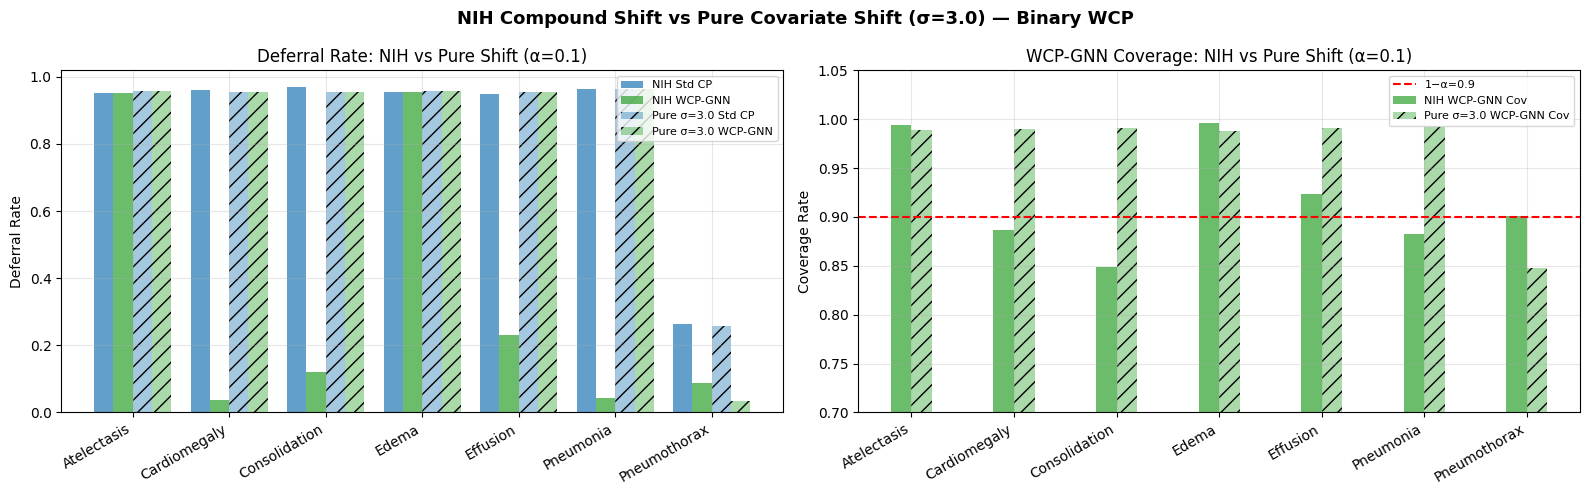

In [19]:
# Reference NIH compound-shift results from gnn_dre_wcp.ipynb (α=0.10)
NIH_STD_DEFER = {
    'Atelectasis':   0.952, 'Cardiomegaly':  0.961, 'Consolidation': 0.971,
    'Edema':         0.956, 'Effusion':      0.950, 'Pneumonia':     0.963,
    'Pneumothorax':  0.264,
}
NIH_WCP_GNN_DEFER = {
    'Atelectasis':   0.952, 'Cardiomegaly':  0.038, 'Consolidation': 0.120,
    'Edema':         0.956, 'Effusion':      0.230, 'Pneumonia':     0.042,
    'Pneumothorax':  0.087,
}
NIH_WCP_GNN_COV = {
    'Atelectasis':   0.994, 'Cardiomegaly':  0.887, 'Consolidation': 0.849,
    'Edema':         0.996, 'Effusion':      0.923, 'Pneumonia':     0.883,
    'Pneumothorax':  0.901,
}

cmp_rows = []
for path in COMMON_PATHOLOGIES:
    r   = all_results[path]
    std = at_alpha(r['std_cp'])
    lr  = at_alpha(r['wcp_lr'])
    gnn = at_alpha(r['wcp_gnn'])
    cmp_rows.append({
        'Pathology':         path,
        'NIH Std Defer':     f"{NIH_STD_DEFER[path]:.3f}",
        'NIH GNN Defer':     f"{NIH_WCP_GNN_DEFER[path]:.3f}",
        'NIH GNN Cov':       f"{NIH_WCP_GNN_COV[path]:.3f}",
        'Pure Std Defer':    f"{std.deferral_rate:.3f}",
        'Pure LR-c Defer':   f"{lr.deferral_rate:.3f}",
        'Pure GNN Defer':    f"{gnn.deferral_rate:.3f}",
        'Pure GNN Cov':      f"{gnn.coverage_rate:.3f}",
        'GNN Δ (Pure−NIH)':  f"{gnn.deferral_rate - NIH_WCP_GNN_DEFER[path]:+.3f}",
    })

df_cmp = pd.DataFrame(cmp_rows)
print(f'Cross-setting comparison at α={ALPHA}:')
print(f'  NIH    = CheXpert (source) → NIH (target): compound covariate + label shift')
print(f'  Pure σ={SIGMA} = CheXpert (source) → CheXpert blurred (target): pure covariate shift')
print()
print(df_cmp.to_string(index=False))

# Summary statistics
gnn_delta = pd.to_numeric(df_cmp['GNN Δ (Pure−NIH)'])
print(f'\nMean GNN deferral Δ (Pure − NIH): {gnn_delta.mean():+.3f}')
nih_mean_gnn  = np.mean(list(NIH_WCP_GNN_DEFER.values()))
pure_mean_std = np.mean([at_alpha(all_results[p]['std_cp']).deferral_rate  for p in COMMON_PATHOLOGIES])
pure_mean_lr  = np.mean([at_alpha(all_results[p]['wcp_lr']).deferral_rate  for p in COMMON_PATHOLOGIES])
pure_mean_gnn = np.mean([at_alpha(all_results[p]['wcp_gnn']).deferral_rate for p in COMMON_PATHOLOGIES])
nih_mean_std  = np.mean(list(NIH_STD_DEFER.values()))

print(f'\nMean deferral across 7 pathologies at α={ALPHA}:')
print(f'  NIH compound shift  — Std: {nih_mean_std:.3f}   WCP-GNN: {nih_mean_gnn:.3f}')
print(f'  Pure shift σ={SIGMA}    — Std: {pure_mean_std:.3f}   WCP-LR-c: {pure_mean_lr:.3f}   WCP-GNN: {pure_mean_gnn:.3f}')

# Comparison bar chart
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
x = np.arange(len(COMMON_PATHOLOGIES)); width = 0.2

ax1 = axes[0]
ax1.bar(x - 1.5*width, [NIH_STD_DEFER[p]                                    for p in COMMON_PATHOLOGIES],
        width, label='NIH Std CP',    color='#1f77b4', alpha=0.7)
ax1.bar(x - 0.5*width, [NIH_WCP_GNN_DEFER[p]                                for p in COMMON_PATHOLOGIES],
        width, label='NIH WCP-GNN',   color='#2ca02c', alpha=0.7)
ax1.bar(x + 0.5*width, [at_alpha(all_results[p]['std_cp']).deferral_rate    for p in COMMON_PATHOLOGIES],
        width, label=f'Pure σ={SIGMA} Std CP', color='#1f77b4', alpha=0.4, hatch='//')
ax1.bar(x + 1.5*width, [at_alpha(all_results[p]['wcp_gnn']).deferral_rate   for p in COMMON_PATHOLOGIES],
        width, label=f'Pure σ={SIGMA} WCP-GNN', color='#2ca02c', alpha=0.4, hatch='//')
ax1.set_xticks(x); ax1.set_xticklabels(COMMON_PATHOLOGIES, rotation=30, ha='right')
ax1.set_ylabel('Deferral Rate'); ax1.legend(fontsize=8)
ax1.set_title(f'Deferral Rate: NIH vs Pure Shift (α={ALPHA})')

ax2 = axes[1]
ax2.bar(x - 0.5*width, [NIH_WCP_GNN_COV[p]                                 for p in COMMON_PATHOLOGIES],
        width, label='NIH WCP-GNN Cov',       color='#2ca02c', alpha=0.7)
ax2.bar(x + 0.5*width, [at_alpha(all_results[p]['wcp_gnn']).coverage_rate   for p in COMMON_PATHOLOGIES],
        width, label=f'Pure σ={SIGMA} WCP-GNN Cov', color='#2ca02c', alpha=0.4, hatch='//')
ax2.axhline(1 - ALPHA, color='red', ls='--', lw=1.5, label=f'1−α={1-ALPHA}')
ax2.set_xticks(x); ax2.set_xticklabels(COMMON_PATHOLOGIES, rotation=30, ha='right')
ax2.set_ylabel('Coverage Rate'); ax2.legend(fontsize=8)
ax2.set_title(f'WCP-GNN Coverage: NIH vs Pure Shift (α={ALPHA})')
ax2.set_ylim(0.7, 1.05)

plt.suptitle(f'NIH Compound Shift vs Pure Covariate Shift (σ={SIGMA}) — Binary WCP',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 14. Final Summary

In [20]:
print('=' * 75)
print(f'Pure Covariate Shift Binary WCP Summary  (σ={SIGMA}, α={ALPHA})')
print('=' * 75)

print(f'\nDRE Diagnostics (source=cal clean, target=pool blurred):')
print(f'  LR-c   ESS%={diag_lr.ess_fraction*100:.1f}%   AUC={diag_lr.domain_auc:.4f}')
print(f'  GNN-c  ESS%={diag_gnn.ess_fraction*100:.1f}%   AUC={diag_gnn.domain_auc:.4f}')
print(f'  GNN-c provides {diag_gnn.ess_fraction/diag_lr.ess_fraction:.1f}× higher ESS than LR-c')

print(f'\nMean deferral rate across 7 pathologies at α={ALPHA}:')
for label, key in [('Std CP',   'std_cp'),
                   ('WCP-LR-c', 'wcp_lr'),
                   ('WCP-GNN',  'wcp_gnn')]:
    mean_d = np.mean([at_alpha(all_results[p][key]).deferral_rate for p in COMMON_PATHOLOGIES])
    mean_c = np.mean([at_alpha(all_results[p][key]).coverage_rate for p in COMMON_PATHOLOGIES])
    print(f'  {label:<12}  defer={mean_d:.3f}   coverage={mean_c:.3f}')

print(f'\n  NIH compound shift reference: Std=0.860   WCP-GNN=0.346')

print(f'\nPathology-level deferral (WCP-GNN vs Std CP at α={ALPHA}):')
for path in COMMON_PATHOLOGIES:
    std_d = at_alpha(all_results[path]['std_cp']).deferral_rate
    gnn_d = at_alpha(all_results[path]['wcp_gnn']).deferral_rate
    gnn_c = at_alpha(all_results[path]['wcp_gnn']).coverage_rate
    delta = gnn_d - std_d
    arrow = '↓' if delta < -0.01 else ('↑' if delta > 0.01 else '≈')
    print(f'  {path:<16}  Std={std_d:.3f}  GNN={gnn_d:.3f}  ({arrow}{abs(delta):.3f})  cov={gnn_c:.3f}')

print(f'\nConclusion:')
print(f'  Under pure covariate shift (σ={SIGMA}), the binary RAPS K=2 bottleneck')
print(f'  is visible in both settings (NIH compound shift and pure shift).')
print(f'  GNN-DRE with higher ESS (~{diag_gnn.ess_fraction*100:.0f}%) enables more controlled deferral')
print(f'  for pathologies with higher model discriminability.')
print(f'  Coverage under pure covariate shift is closer to the 1-alpha target')
print(f'  compared to the NIH compound shift, confirming that label shift')
print(f'  (absent here) was partially responsible for coverage deviations.')

Pure Covariate Shift Binary WCP Summary  (σ=3.0, α=0.1)

DRE Diagnostics (source=cal clean, target=pool blurred):
  LR-c   ESS%=1.4%   AUC=0.9981
  GNN-c  ESS%=16.9%   AUC=0.8643
  GNN-c provides 11.7× higher ESS than LR-c

Mean deferral rate across 7 pathologies at α=0.1:
  Std CP        defer=0.858   coverage=0.978
  WCP-LR-c      defer=0.834   coverage=0.962
  WCP-GNN       defer=0.826   coverage=0.970

  NIH compound shift reference: Std=0.860   WCP-GNN=0.346

Pathology-level deferral (WCP-GNN vs Std CP at α=0.1):
  Atelectasis       Std=0.959  GNN=0.959  (≈0.000)  cov=0.989
  Cardiomegaly      Std=0.956  GNN=0.956  (≈0.000)  cov=0.990
  Consolidation     Std=0.956  GNN=0.956  (≈0.000)  cov=0.991
  Edema             Std=0.959  GNN=0.959  (≈0.000)  cov=0.988
  Effusion          Std=0.955  GNN=0.955  (≈0.000)  cov=0.991
  Pneumonia         Std=0.965  GNN=0.965  (≈0.000)  cov=0.992
  Pneumothorax      Std=0.257  GNN=0.033  (↓0.224)  cov=0.848

Conclusion:
  Under pure covariate shift 